# 📈 Stock Price Prediction of Top 10 Indian Companies
## Using Machine Learning & Deep Learning (Linear Regression + LSTM)
**Author:** Data Science Project | Python | yfinance | Keras | Scikit-learn

---
> This notebook predicts stock prices for the top 10 Indian companies listed on NSE.
> Models used: **Linear Regression** and **LSTM (Long Short-Term Memory)**

In [1]:
pip install -r requirements.txt

^C
Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install tensorflow

In [ ]:
pip install streamlit

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 📦 SECTION 1: Import Libraries

In [ ]:
# ─────────────────────────────────────────────────────────────
# SECTION 1: IMPORT ALL REQUIRED LIBRARIES
# ─────────────────────────────────────────────────────────────

# Standard libraries
import warnings
warnings.filterwarnings('ignore')
import os
import math
import datetime

# Data manipulation
import numpy as np
import pandas as pd

# Stock data fetching
import yfinance as yf

# Visualization
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
plt.style.use('seaborn-v0_8-darkgrid')

# Preprocessing & ML
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

# Deep Learning (LSTM)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Suppress TF logs
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
tf.get_logger().setLevel('ERROR')

print('✅ All libraries imported successfully!')
print(f'   TensorFlow version : {tf.__version__}')
print(f'   NumPy version      : {np.__version__}')
print(f'   Pandas version     : {pd.__version__}')

ModuleNotFoundError: No module named 'tensorflow'

## 🏢 SECTION 2: Define Stocks & Fetch Data

In [ ]:
# ─────────────────────────────────────────────────────────────
# SECTION 2: DEFINE TOP 10 INDIAN STOCKS & FETCH DATA
# ─────────────────────────────────────────────────────────────

# Top 10 Indian companies listed on NSE (.NS = National Stock Exchange)
STOCKS = {
    'RELIANCE.NS'  : 'Reliance Industries',
    'TCS.NS'       : 'Tata Consultancy Services',
    'INFY.NS'      : 'Infosys',
    'HDFCBANK.NS'  : 'HDFC Bank',
    'ICICIBANK.NS' : 'ICICI Bank',
    'ITC.NS'       : 'ITC Limited',
    'SBIN.NS'      : 'State Bank of India',
    'LT.NS'        : 'Larsen & Toubro',
    'HINDUNILVR.NS': 'Hindustan Unilever',
    'WIPRO.NS'     : 'Wipro'
}

# Date range: 5 years of historical data
END_DATE   = datetime.date.today()
START_DATE = END_DATE - datetime.timedelta(days=5*365)

print(f'📅 Fetching data from {START_DATE} to {END_DATE}')
print(f'📊 Total stocks      : {len(STOCKS)}\n')

# ── Download all stock data into a dictionary ──────────────────
all_data = {}

for ticker, name in STOCKS.items():
    try:
        df = yf.download(ticker, start=START_DATE, end=END_DATE,
                         progress=False, auto_adjust=True)
        if df.empty:
            print(f'  ⚠️  No data for {ticker}')
            continue
        # Flatten MultiIndex columns if present
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.get_level_values(0)
        df.dropna(inplace=True)
        all_data[ticker] = df
        print(f'  ✅ {name:35s} | Rows: {len(df):5d} | '
              f'Latest Close: ₹{df["Close"].iloc[-1]:.2f}')
    except Exception as e:
        print(f'  ❌ Error fetching {ticker}: {e}')

print(f'\n🎯 Successfully loaded {len(all_data)} stocks!')

📅 Fetching data from 2021-04-27 to 2026-04-26
📊 Total stocks      : 10

  ✅ Reliance Industries                 | Rows:  1236 | Latest Close: ₹1327.80
  ✅ Tata Consultancy Services           | Rows:  1236 | Latest Close: ₹2396.90
  ✅ Infosys                             | Rows:  1236 | Latest Close: ₹1154.60
  ✅ HDFC Bank                           | Rows:  1236 | Latest Close: ₹784.85
  ✅ ICICI Bank                          | Rows:  1236 | Latest Close: ₹1326.20
  ✅ ITC Limited                         | Rows:  1236 | Latest Close: ₹301.60
  ✅ State Bank of India                 | Rows:  1236 | Latest Close: ₹1101.10
  ✅ Larsen & Toubro                     | Rows:  1236 | Latest Close: ₹4014.30
  ✅ Hindustan Unilever                  | Rows:  1236 | Latest Close: ₹2327.30
  ✅ Wipro                               | Rows:  1236 | Latest Close: ₹199.36

🎯 Successfully loaded 10 stocks!


## 🧹 SECTION 3: Data Cleaning & Preprocessing

In [ ]:
# ─────────────────────────────────────────────────────────────
# SECTION 3: DATA CLEANING & PREPROCESSING
# ─────────────────────────────────────────────────────────────

def clean_stock_data(df, ticker):
    """Clean and preprocess raw stock data."""
    df = df.copy()

    # 1. Drop rows with missing values
    before = len(df)
    df.dropna(inplace=True)
    after = len(df)
    dropped = before - after

    # 2. Remove duplicate index entries (same date twice)
    df = df[~df.index.duplicated(keep='first')]

    # 3. Sort by date (oldest → newest)
    df.sort_index(inplace=True)

    # 4. Ensure the index is DatetimeIndex
    df.index = pd.to_datetime(df.index)

    # 5. Add 'Ticker' column for identification
    df['Ticker'] = ticker

    # 6. Basic sanity: remove rows where Close <= 0
    df = df[df['Close'] > 0]

    return df, dropped

# Apply cleaning to all stocks
clean_data = {}
print('Stock Data Summary After Cleaning:\n')
print(f'{"Ticker":<18} {"Rows":<8} {"Dropped":<10} {"Min Close":>12} {"Max Close":>12} {"Avg Close":>12}')
print('─' * 76)

for ticker, df in all_data.items():
    cleaned_df, dropped = clean_stock_data(df, ticker)
    clean_data[ticker] = cleaned_df
    print(f'{ticker:<18} {len(cleaned_df):<8} {dropped:<10} '
          f'{cleaned_df["Close"].min():>12.2f} '
          f'{cleaned_df["Close"].max():>12.2f} '
          f'{cleaned_df["Close"].mean():>12.2f}')

# Show a sample of one stock's cleaned data
sample_ticker = list(clean_data.keys())[0]
print(f'\n📋 Sample Data — {STOCKS[sample_ticker]}:')
print(clean_data[sample_ticker][['Open','High','Low','Close','Volume']].tail(5))

Stock Data Summary After Cleaning:

Ticker             Rows     Dropped       Min Close    Max Close    Avg Close
────────────────────────────────────────────────────────────────────────────
RELIANCE.NS        1236     0                867.48      1592.30      1251.13
TCS.NS             1236     0               2356.00      4311.59      3256.84
INFY.NS            1236     0               1122.01      1942.22      1478.57
HDFCBANK.NS        1236     0                616.52      1012.90       796.34
ICICIBANK.NS       1236     0                572.14      1477.20      1018.12
ITC.NS             1236     0                156.91       476.59       329.28
SBIN.NS            1236     0                323.50      1227.80       650.19
LT.NS              1236     0               1269.31      4418.10      2745.62
HINDUNILVR.NS      1236     0               1811.67      2939.45      2357.59
WIPRO.NS           1236     0                166.60       333.30       232.53

📋 Sample Data — Reliance Ind

## 📊 SECTION 4: Data Visualization

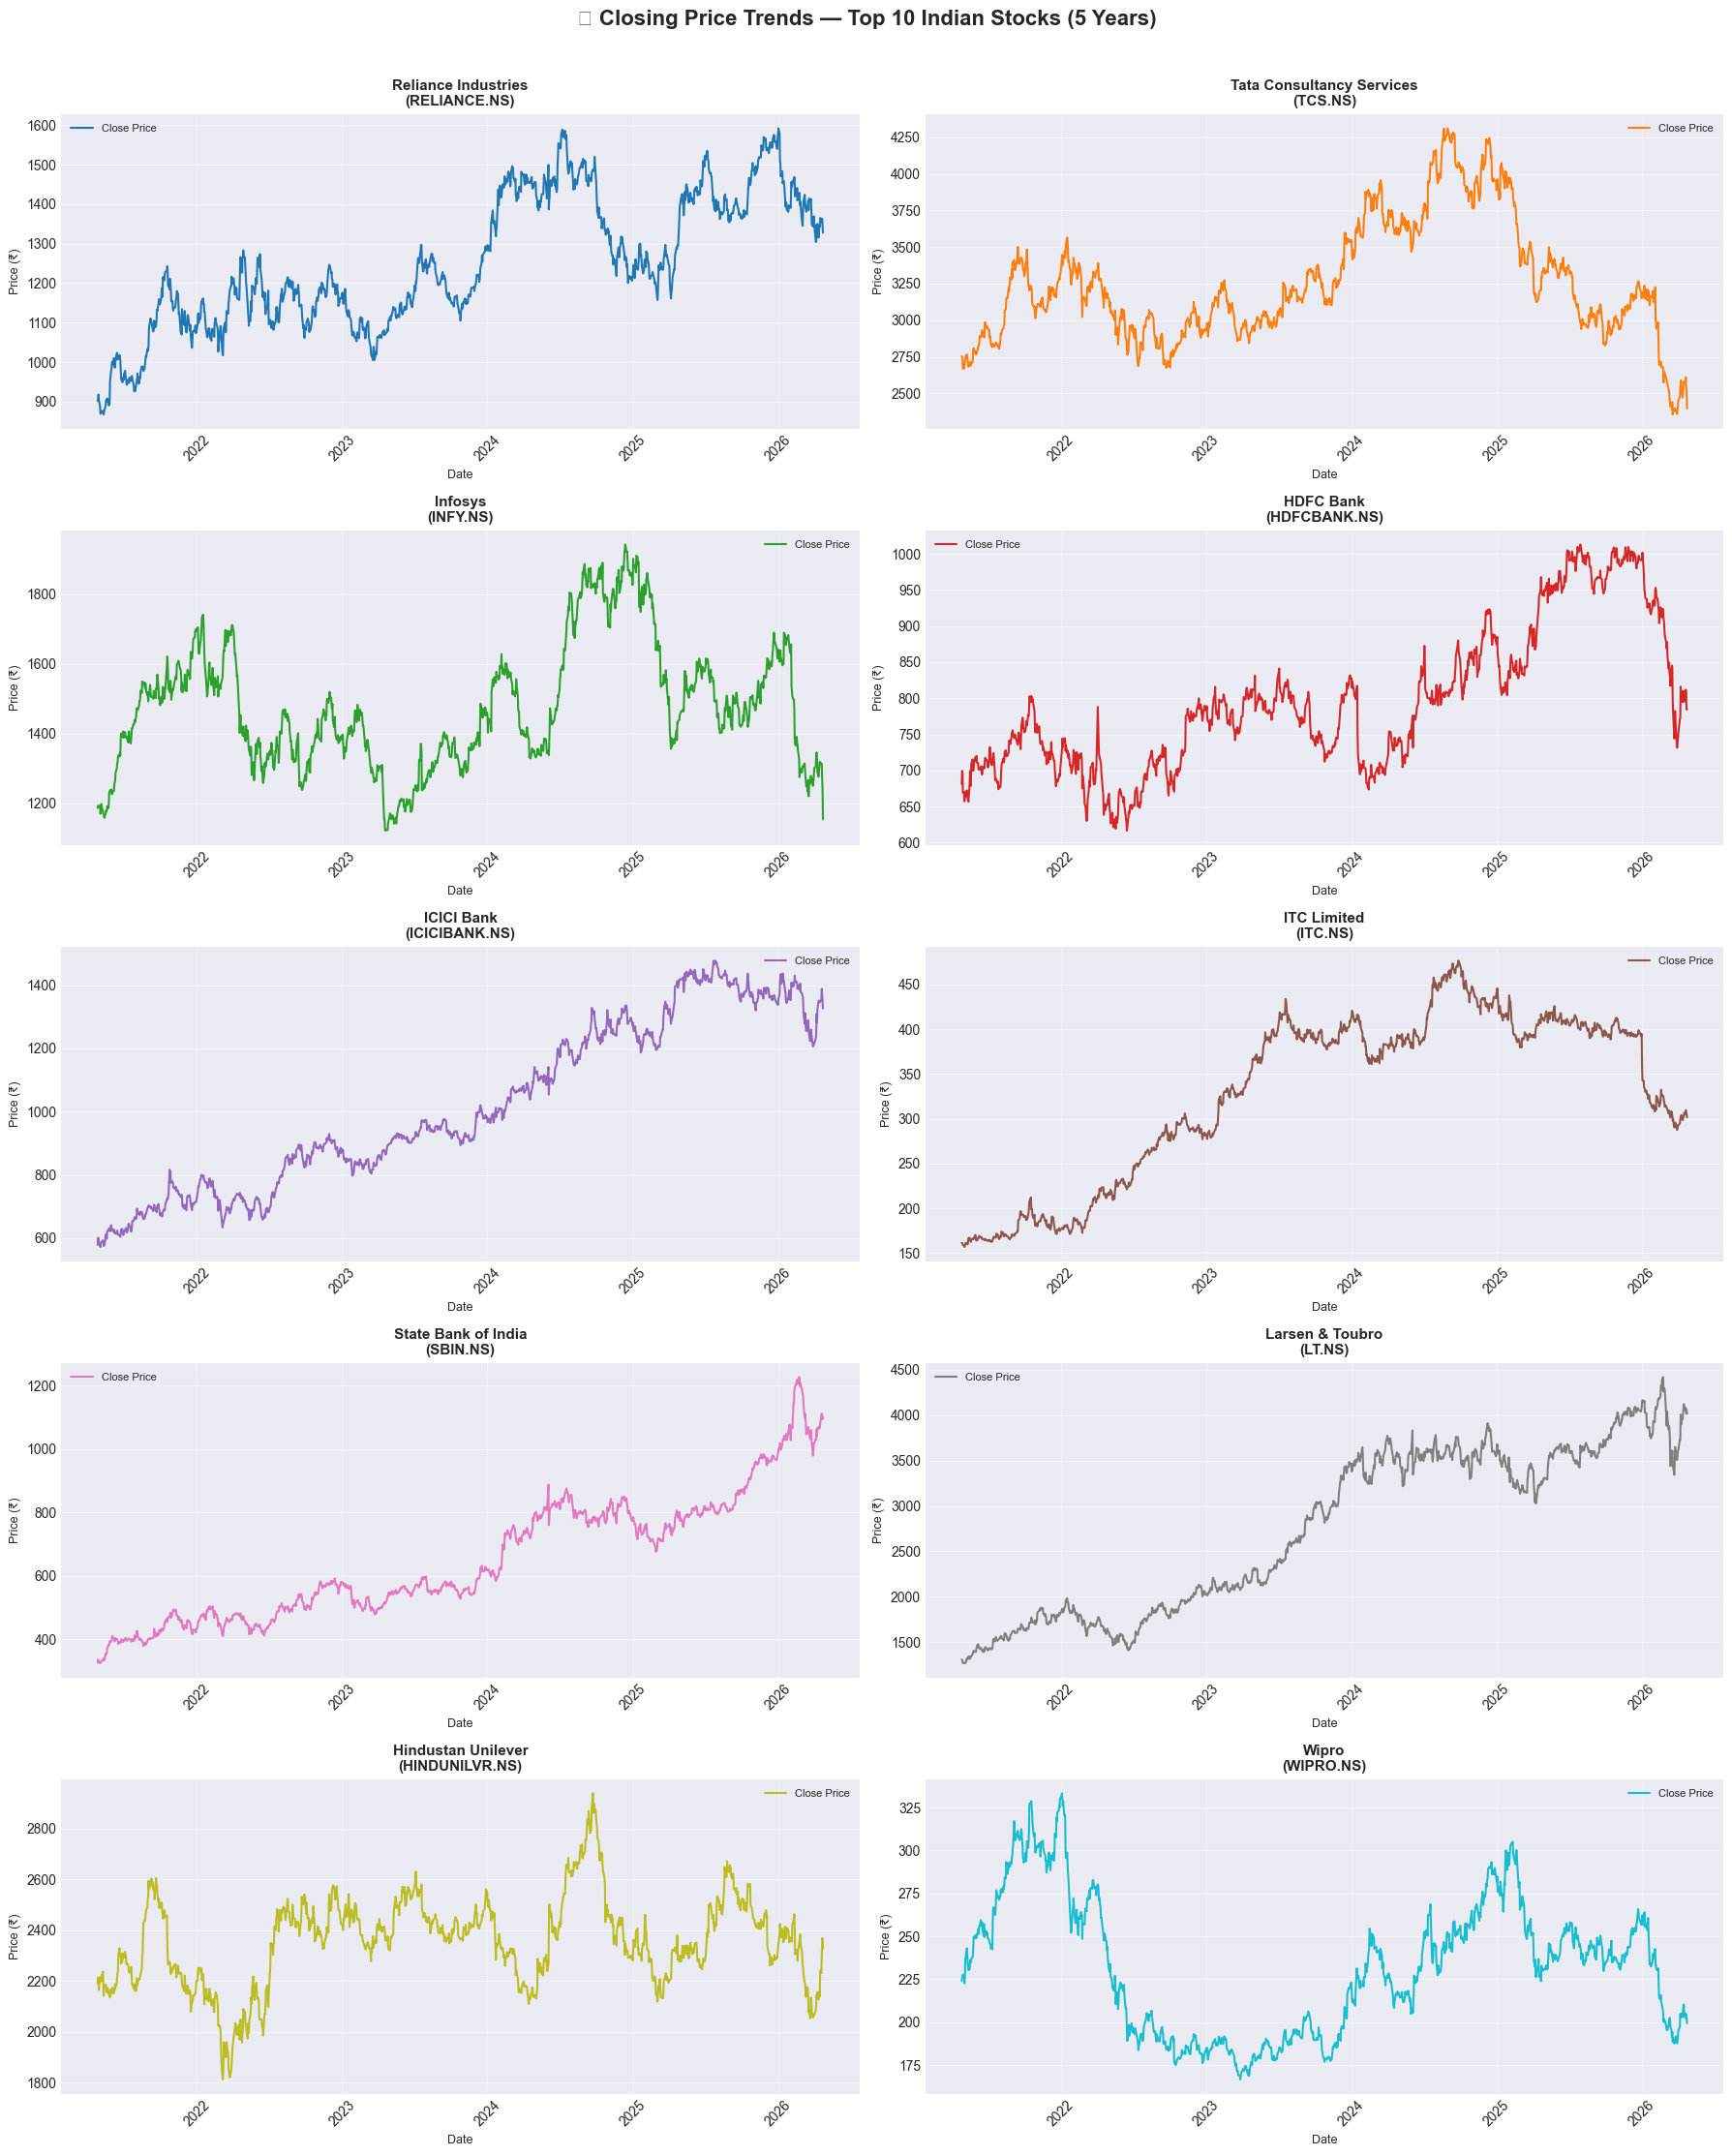

✅ Chart saved: closing_price_trends.png


In [ ]:
# ─────────────────────────────────────────────────────────────
# SECTION 4A: CLOSING PRICE TRENDS – ALL 10 COMPANIES
# ─────────────────────────────────────────────────────────────

fig, axes = plt.subplots(5, 2, figsize=(18, 22))
axes = axes.flatten()
colors = plt.cm.tab10(np.linspace(0, 1, 10))

for idx, (ticker, df) in enumerate(clean_data.items()):
    ax = axes[idx]
    ax.plot(df.index, df['Close'], color=colors[idx], linewidth=1.5, label='Close Price')
    ax.set_title(f'{STOCKS[ticker]}\n({ticker})', fontsize=11, fontweight='bold')
    ax.set_xlabel('Date', fontsize=9)
    ax.set_ylabel('Price (₹)', fontsize=9)
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.4)

plt.suptitle('📈 Closing Price Trends — Top 10 Indian Stocks (5 Years)',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('closing_price_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart saved: closing_price_trends.png')

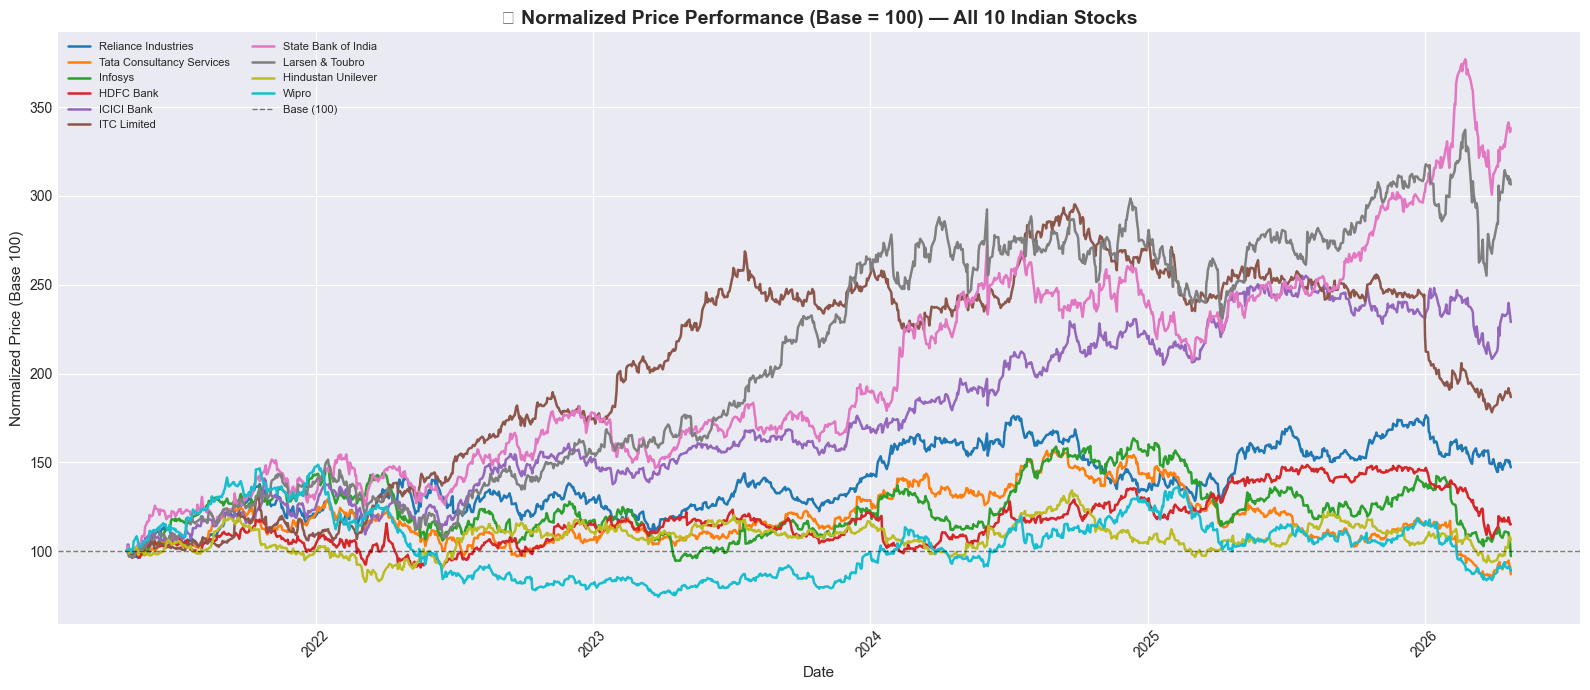

✅ Chart saved: normalized_comparison.png


In [ ]:
# ─────────────────────────────────────────────────────────────
# SECTION 4B: NORMALIZED PRICE COMPARISON (All stocks on 1 chart)
# ─────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(16, 7))

for idx, (ticker, df) in enumerate(clean_data.items()):
    # Normalize: each stock starts at 100 on day 1
    normalized = (df['Close'] / df['Close'].iloc[0]) * 100
    ax.plot(df.index, normalized, label=STOCKS[ticker], color=colors[idx], linewidth=1.8)

ax.axhline(y=100, color='black', linestyle='--', linewidth=1, alpha=0.5, label='Base (100)')
ax.set_title('📊 Normalized Price Performance (Base = 100) — All 10 Indian Stocks',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Normalized Price (Base 100)', fontsize=11)
ax.legend(loc='upper left', fontsize=8, ncol=2)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('normalized_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart saved: normalized_comparison.png')

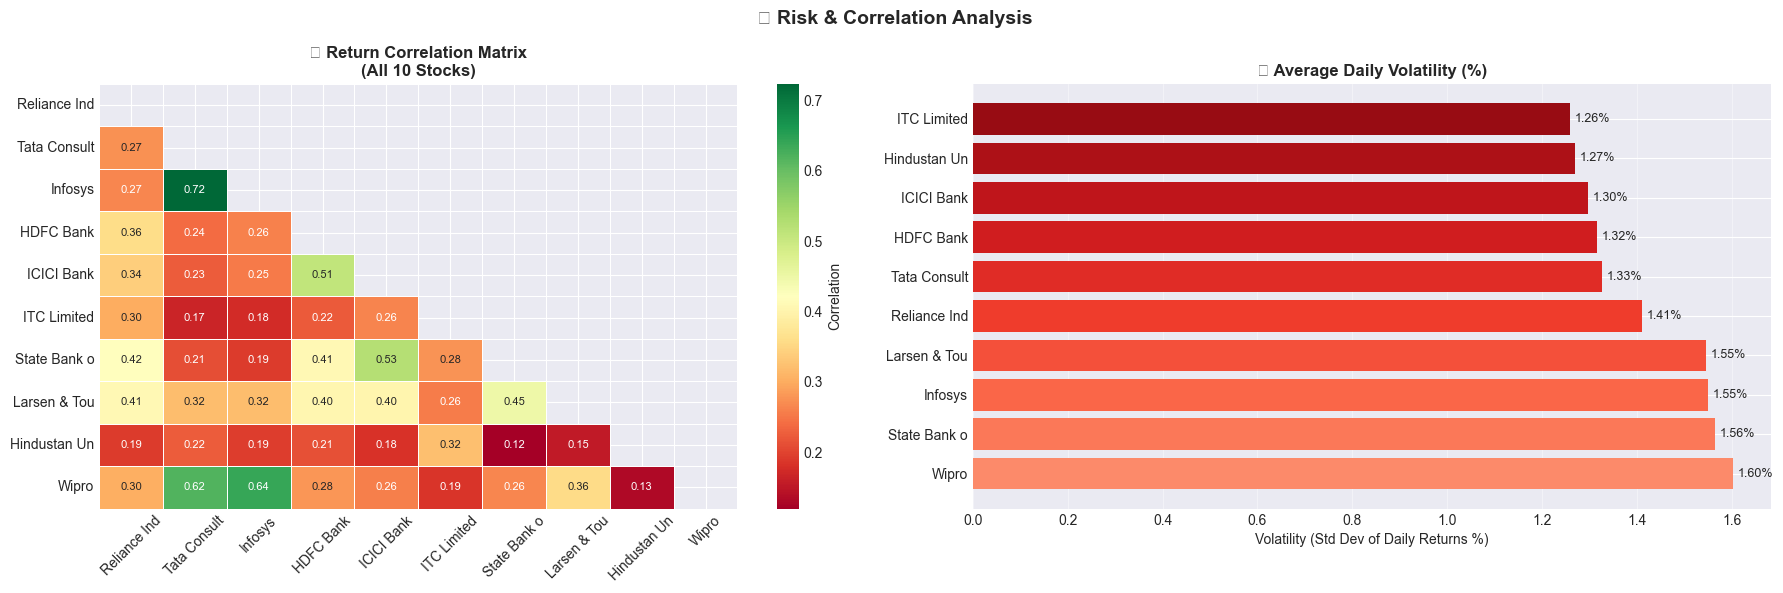

✅ Chart saved: correlation_volatility.png


In [ ]:
# ─────────────────────────────────────────────────────────────
# SECTION 4C: VOLUME & VOLATILITY ANALYSIS
# ─────────────────────────────────────────────────────────────

# Daily returns heatmap (correlation matrix)
returns_df = pd.DataFrame()
for ticker, df in clean_data.items():
    returns_df[STOCKS[ticker][:12]] = df['Close'].pct_change()  # daily % return

returns_df.dropna(inplace=True)
corr_matrix = returns_df.corr()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Left: Correlation Heatmap
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            mask=mask, ax=axes[0], linewidths=0.5,
            cbar_kws={'label': 'Correlation'},
            annot_kws={'size': 8})
axes[0].set_title('🔗 Return Correlation Matrix\n(All 10 Stocks)', fontweight='bold', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

# Right: Average Daily Volatility (Std of daily returns)
volatility = returns_df.std().sort_values(ascending=False) * 100
bars = axes[1].barh(volatility.index, volatility.values,
                    color=plt.cm.Reds(np.linspace(0.4, 0.9, len(volatility))))
axes[1].set_title('📉 Average Daily Volatility (%)', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Volatility (Std Dev of Daily Returns %)')
for bar, val in zip(bars, volatility.values):
    axes[1].text(val + 0.01, bar.get_y() + bar.get_height()/2,
                 f'{val:.2f}%', va='center', fontsize=9)
axes[1].grid(axis='x', alpha=0.4)

plt.suptitle('📈 Risk & Correlation Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_volatility.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart saved: correlation_volatility.png')

## ⚙️ SECTION 5: Feature Engineering

In [ ]:
# ─────────────────────────────────────────────────────────────
# SECTION 5: FEATURE ENGINEERING
# Add technical indicators used in real stock analysis
# ─────────────────────────────────────────────────────────────

def add_features(df):
    """Add technical indicators as features for ML models."""
    df = df.copy()

    # ── Moving Averages (trend indicators) ──────────────────────
    df['MA_7']   = df['Close'].rolling(window=7).mean()    # 1-week MA
    df['MA_21']  = df['Close'].rolling(window=21).mean()   # 1-month MA
    df['MA_50']  = df['Close'].rolling(window=50).mean()   # 50-day MA
    df['MA_200'] = df['Close'].rolling(window=200).mean()  # 200-day MA

    # ── Exponential Moving Average (gives more weight to recent data) ──
    df['EMA_12'] = df['Close'].ewm(span=12, adjust=False).mean()
    df['EMA_26'] = df['Close'].ewm(span=26, adjust=False).mean()

    # ── MACD (Moving Average Convergence Divergence) ────────────
    df['MACD']        = df['EMA_12'] - df['EMA_26']
    df['MACD_Signal'] = df['MACD'].ewm(span=9, adjust=False).mean()
    df['MACD_Hist']   = df['MACD'] - df['MACD_Signal']

    # ── Bollinger Bands (volatility bands) ──────────────────────
    rolling_std       = df['Close'].rolling(window=20).std()
    df['BB_Mid']      = df['Close'].rolling(window=20).mean()
    df['BB_Upper']    = df['BB_Mid'] + (2 * rolling_std)
    df['BB_Lower']    = df['BB_Mid'] - (2 * rolling_std)
    df['BB_Width']    = (df['BB_Upper'] - df['BB_Lower']) / df['BB_Mid']

    # ── RSI — Relative Strength Index (momentum oscillator) ─────
    delta     = df['Close'].diff()
    gain      = delta.clip(lower=0)
    loss      = -delta.clip(upper=0)
    avg_gain  = gain.rolling(window=14).mean()
    avg_loss  = loss.rolling(window=14).mean()
    rs        = avg_gain / (avg_loss + 1e-10)
    df['RSI'] = 100 - (100 / (1 + rs))

    # ── Daily Return & Price Change ──────────────────────────────
    df['Daily_Return']   = df['Close'].pct_change() * 100
    df['Price_Change']   = df['Close'] - df['Open']
    df['High_Low_Range'] = df['High'] - df['Low']

    # ── Volume-based features ───────────────────────────────────
    df['Volume_MA_10'] = df['Volume'].rolling(window=10).mean()
    df['Volume_Ratio'] = df['Volume'] / (df['Volume_MA_10'] + 1e-10)

    # ── Lag Features (previous day's close prices) ───────────────
    for lag in [1, 2, 3, 5]:
        df[f'Lag_{lag}'] = df['Close'].shift(lag)

    # ── Target: Next day's closing price ────────────────────────
    df['Target'] = df['Close'].shift(-1)

    # Drop rows with NaN values introduced by rolling windows
    df.dropna(inplace=True)

    return df

# Apply feature engineering to all stocks
featured_data = {}
for ticker, df in clean_data.items():
    featured_data[ticker] = add_features(df)

# Print feature list
sample = list(featured_data.values())[0]
feature_cols = [c for c in sample.columns if c not in ['Target', 'Ticker']]
print('✅ Feature Engineering complete!')
print(f'   Total features created : {len(feature_cols)}')
print(f'   Feature list           : {feature_cols}')
print(f'\n📋 Sample (last 3 rows of {list(STOCKS.keys())[0]}):')
print(sample[['Close','MA_7','MA_21','RSI','MACD','BB_Width','Target']].tail(3))

✅ Feature Engineering complete!
   Total features created : 28
   Feature list           : ['Close', 'High', 'Low', 'Open', 'Volume', 'MA_7', 'MA_21', 'MA_50', 'MA_200', 'EMA_12', 'EMA_26', 'MACD', 'MACD_Signal', 'MACD_Hist', 'BB_Mid', 'BB_Upper', 'BB_Lower', 'BB_Width', 'RSI', 'Daily_Return', 'Price_Change', 'High_Low_Range', 'Volume_MA_10', 'Volume_Ratio', 'Lag_1', 'Lag_2', 'Lag_3', 'Lag_5']

📋 Sample (last 3 rows of RELIANCE.NS):
Price             Close         MA_7        MA_21        RSI       MACD  \
Date                                                                      
2026-04-21  1353.300049  1347.757150  1360.623814  50.950307 -12.882722   
2026-04-22  1362.099976  1349.457153  1358.433338  53.271023 -11.063218   
2026-04-23  1343.400024  1353.500017  1356.461908  45.250377 -11.003338   

Price       BB_Width       Target  
Date                               
2026-04-21  0.099702  1362.099976  
2026-04-22  0.098132  1343.400024  
2026-04-23  0.090237  1327.800049  


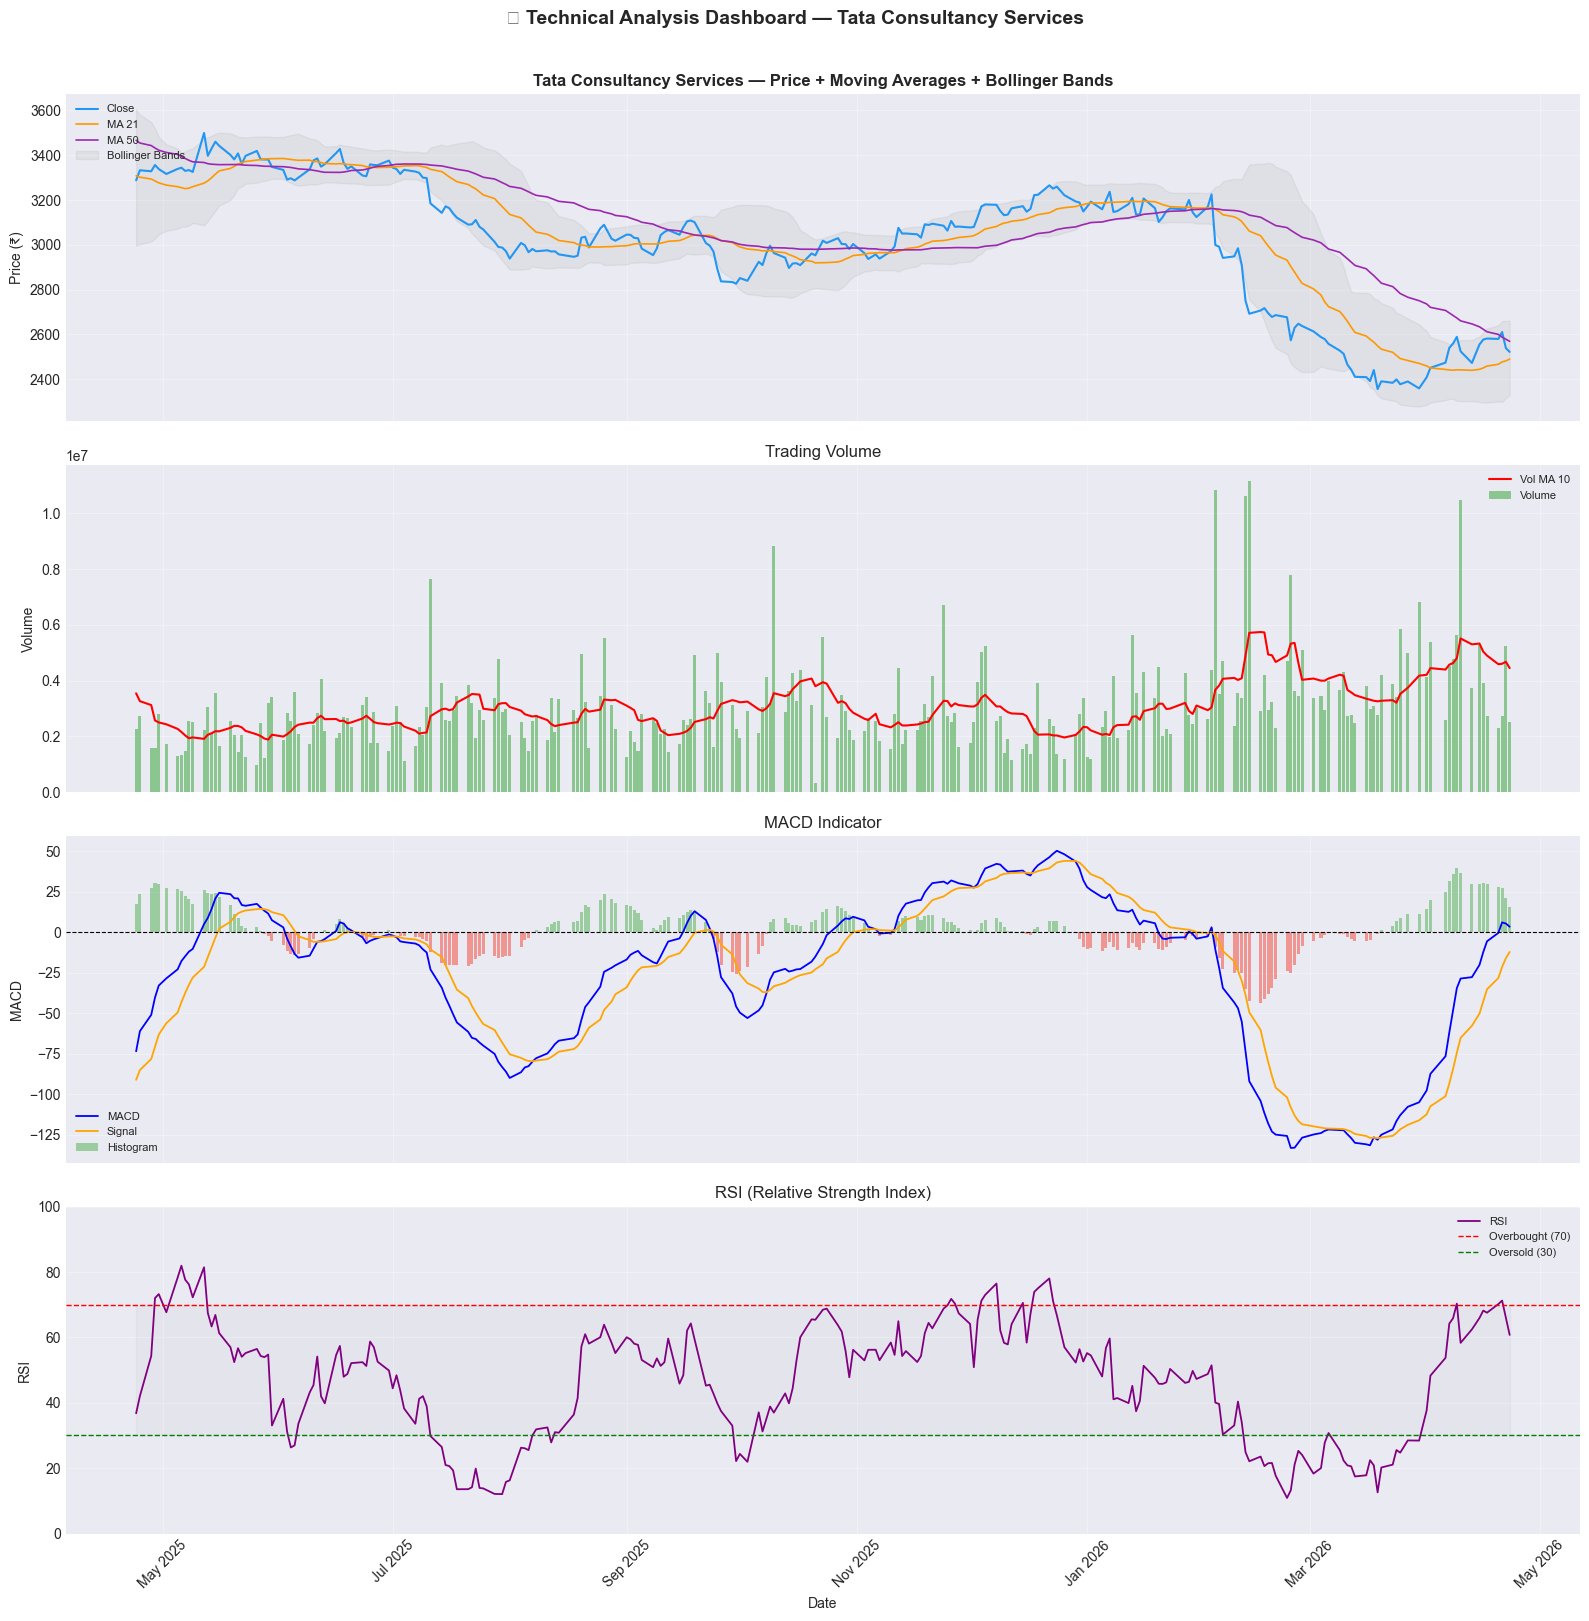

✅ Chart saved: technical_indicators.png


In [ ]:
# ─────────────────────────────────────────────────────────────
# SECTION 5B: VISUALIZE TECHNICAL INDICATORS (TCS example)
# ─────────────────────────────────────────────────────────────

demo_ticker = 'TCS.NS'
demo_df     = featured_data[demo_ticker].copy()
demo_recent = demo_df.last('365D')  # Last 1 year

fig, axes = plt.subplots(4, 1, figsize=(16, 16), sharex=True)

# 1. Price + Moving Averages
axes[0].plot(demo_recent.index, demo_recent['Close'],  label='Close',  color='#2196F3', lw=1.5)
axes[0].plot(demo_recent.index, demo_recent['MA_21'],  label='MA 21',  color='#FF9800', lw=1.2)
axes[0].plot(demo_recent.index, demo_recent['MA_50'],  label='MA 50',  color='#9C27B0', lw=1.2)
axes[0].fill_between(demo_recent.index,
                     demo_recent['BB_Lower'], demo_recent['BB_Upper'],
                     alpha=0.1, color='gray', label='Bollinger Bands')
axes[0].set_title(f'{STOCKS[demo_ticker]} — Price + Moving Averages + Bollinger Bands',
                  fontweight='bold')
axes[0].set_ylabel('Price (₹)')
axes[0].legend(loc='upper left', fontsize=8)

# 2. Volume
axes[1].bar(demo_recent.index, demo_recent['Volume'], color='#4CAF50', alpha=0.6, label='Volume')
axes[1].plot(demo_recent.index, demo_recent['Volume_MA_10'], color='red', lw=1.5, label='Vol MA 10')
axes[1].set_ylabel('Volume')
axes[1].set_title('Trading Volume')
axes[1].legend(fontsize=8)

# 3. MACD
axes[2].plot(demo_recent.index, demo_recent['MACD'],        color='blue',  lw=1.3, label='MACD')
axes[2].plot(demo_recent.index, demo_recent['MACD_Signal'], color='orange',lw=1.3, label='Signal')
axes[2].bar(demo_recent.index, demo_recent['MACD_Hist'],
            color=np.where(demo_recent['MACD_Hist'] > 0, '#4CAF50', '#F44336'),
            alpha=0.5, label='Histogram')
axes[2].axhline(0, color='black', lw=0.8, linestyle='--')
axes[2].set_ylabel('MACD')
axes[2].set_title('MACD Indicator')
axes[2].legend(fontsize=8)

# 4. RSI
axes[3].plot(demo_recent.index, demo_recent['RSI'], color='purple', lw=1.3, label='RSI')
axes[3].axhline(70, color='red',   lw=1, linestyle='--', label='Overbought (70)')
axes[3].axhline(30, color='green', lw=1, linestyle='--', label='Oversold (30)')
axes[3].fill_between(demo_recent.index, 30, 70, alpha=0.05, color='gray')
axes[3].set_ylim(0, 100)
axes[3].set_ylabel('RSI')
axes[3].set_title('RSI (Relative Strength Index)')
axes[3].legend(fontsize=8)
axes[3].set_xlabel('Date')

for ax in axes:
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.tick_params(axis='x', rotation=45)

plt.suptitle(f'📉 Technical Analysis Dashboard — {STOCKS[demo_ticker]}',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('technical_indicators.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart saved: technical_indicators.png')

## 🤖 SECTION 6: Model 1 — Linear Regression

In [ ]:
# ─────────────────────────────────────────────────────────────
# SECTION 6: LINEAR REGRESSION MODEL
# Features → predict next day's closing price
# ─────────────────────────────────────────────────────────────

# Features used for Linear Regression
LR_FEATURES = [
    'Close', 'Open', 'High', 'Low', 'Volume',
    'MA_7', 'MA_21', 'MA_50', 'EMA_12', 'EMA_26',
    'MACD', 'RSI', 'BB_Width', 'BB_Upper', 'BB_Lower',
    'Daily_Return', 'High_Low_Range', 'Volume_Ratio',
    'Lag_1', 'Lag_2', 'Lag_3', 'Lag_5'
]

lr_results = {}  # Store results for all stocks

def train_linear_regression(df, ticker, test_size=0.2):
    """Train a Linear Regression model on one stock."""

    # Select available features
    available = [f for f in LR_FEATURES if f in df.columns]
    X = df[available].values
    y = df['Target'].values

    # Train-Test Split (no shuffle — time-series order matters!)
    split_idx = int(len(X) * (1 - test_size))
    X_train, X_test = X[:split_idx], X[split_idx:]
    y_train, y_test = y[:split_idx], y[split_idx:]
    dates_test      = df.index[split_idx:]

    # Scale features (Linear Regression is sensitive to scale)
    scaler   = MinMaxScaler()
    X_train  = scaler.fit_transform(X_train)
    X_test   = scaler.transform(X_test)

    # Train the model
    model = LinearRegression()
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Metrics
    rmse = math.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)
    mape = np.mean(np.abs((y_test - y_pred) / (y_test + 1e-10))) * 100

    return {
        'model'     : model,
        'scaler'    : scaler,
        'features'  : available,
        'y_test'    : y_test,
        'y_pred'    : y_pred,
        'dates_test': dates_test,
        'rmse'      : rmse,
        'mae'       : mae,
        'r2'        : r2,
        'mape'      : mape,
        'X_last'    : scaler.transform(X[-1:])  # Last row for future prediction
    }

# Train Linear Regression for all 10 stocks
print('Training Linear Regression on all stocks...\n')
print(f'{"Stock":<18} {"RMSE":>10} {"MAE":>10} {"R²":>8} {"MAPE":>8}')
print('─' * 60)

for ticker, df in featured_data.items():
    result = train_linear_regression(df, ticker)
    lr_results[ticker] = result
    print(f'{ticker:<18} {result["rmse"]:>10.2f} {result["mae"]:>10.2f} '
          f'{result["r2"]:>8.4f} {result["mape"]:>7.2f}%')

print('\n✅ Linear Regression training complete!')

Training Linear Regression on all stocks...

Stock                    RMSE        MAE       R²     MAPE
────────────────────────────────────────────────────────────
RELIANCE.NS             18.12      13.59   0.9324    0.95%
TCS.NS                  43.10      30.75   0.9723    1.06%
INFY.NS                 24.68      17.54   0.9590    1.21%
HDFCBANK.NS             10.56       7.78   0.9775    0.86%
ICICIBANK.NS            15.93      12.08   0.9099    0.89%
ITC.NS                   4.53       2.98   0.9889    0.84%
SBIN.NS                 13.99       9.56   0.9868    0.97%
LT.NS                   64.26      42.33   0.9268    1.11%
HINDUNILVR.NS           31.19      22.77   0.9518    0.96%
WIPRO.NS                 3.55       2.60   0.9693    1.12%

✅ Linear Regression training complete!


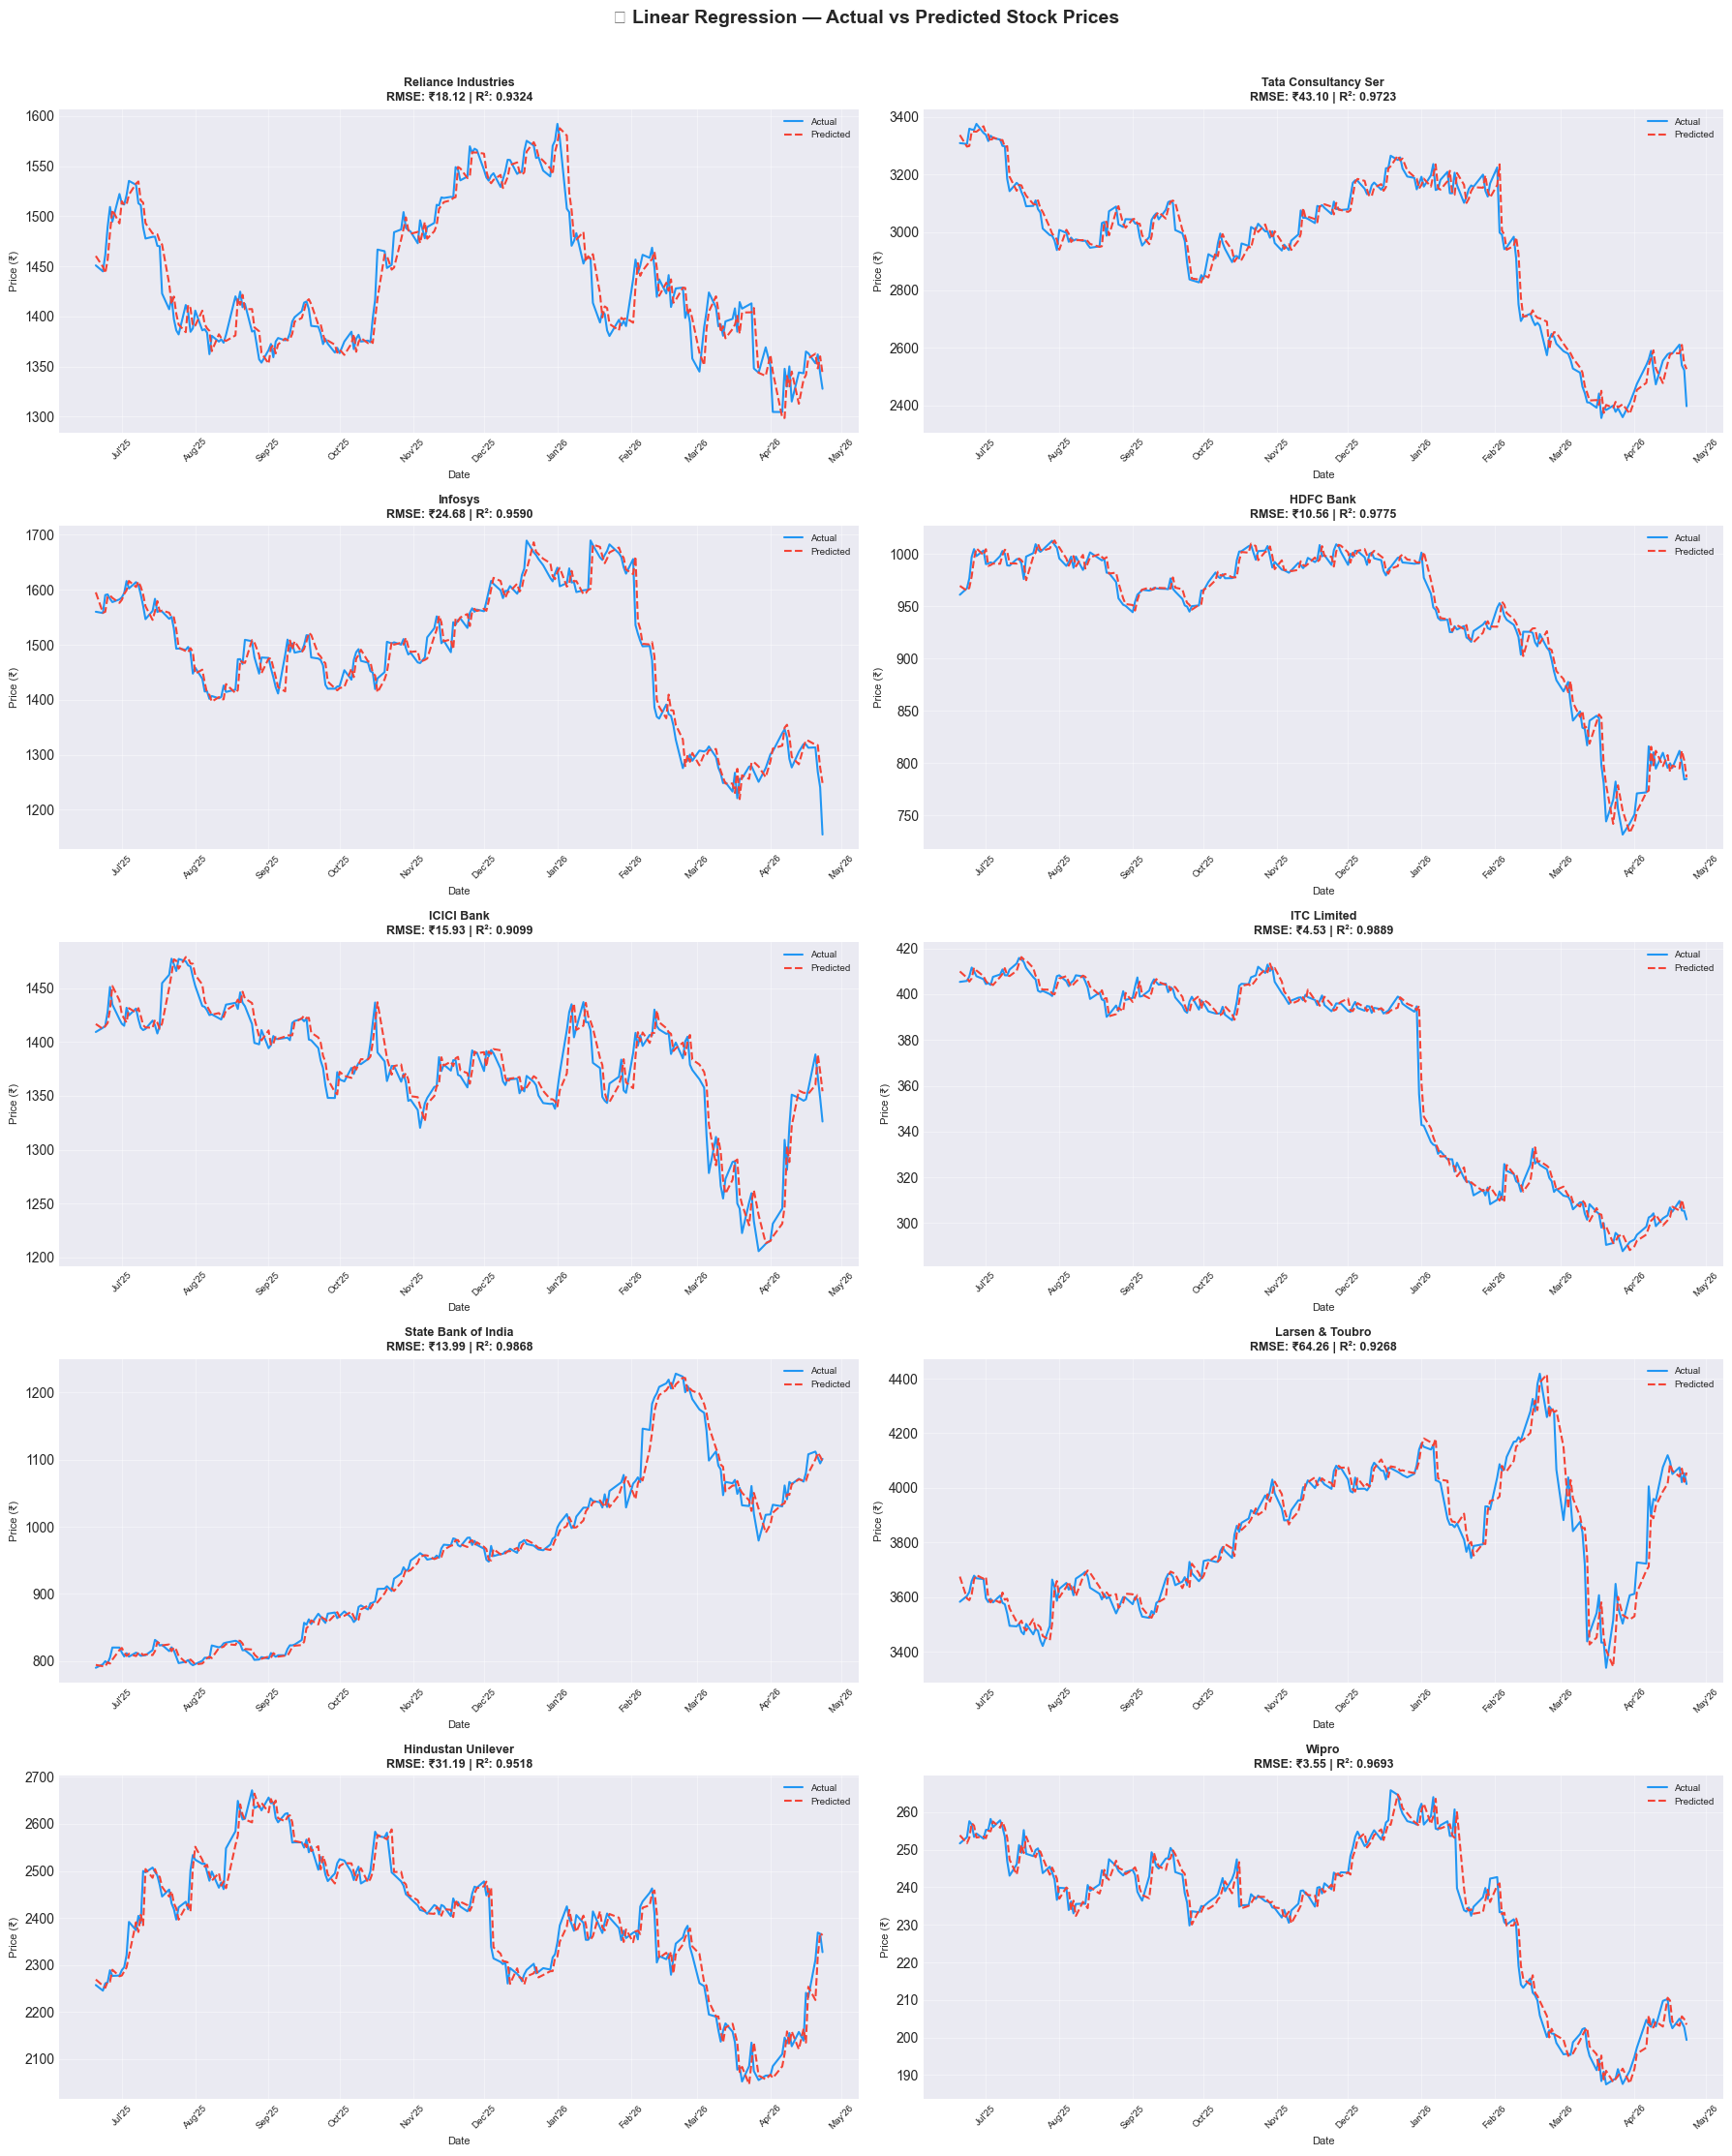

✅ Chart saved: lr_predictions.png


In [ ]:
# ─────────────────────────────────────────────────────────────
# SECTION 6B: PLOT LINEAR REGRESSION PREDICTIONS
# ─────────────────────────────────────────────────────────────

fig, axes = plt.subplots(5, 2, figsize=(18, 22))
axes = axes.flatten()

for idx, (ticker, res) in enumerate(lr_results.items()):
    ax = axes[idx]
    ax.plot(res['dates_test'], res['y_test'], label='Actual',    color='#2196F3', lw=1.5)
    ax.plot(res['dates_test'], res['y_pred'], label='Predicted', color='#F44336', lw=1.5,
            linestyle='--')
    ax.set_title(f'{STOCKS[ticker][:20]}\nRMSE: ₹{res["rmse"]:.2f} | R²: {res["r2"]:.4f}',
                 fontsize=9, fontweight='bold')
    ax.set_xlabel('Date', fontsize=8)
    ax.set_ylabel('Price (₹)', fontsize=8)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.4)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\'%y'))
    ax.tick_params(axis='x', rotation=45, labelsize=7)

plt.suptitle('📊 Linear Regression — Actual vs Predicted Stock Prices',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('lr_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart saved: lr_predictions.png')

## 🧠 SECTION 7: Model 2 — LSTM (Deep Learning)

In [ ]:
# ─────────────────────────────────────────────────────────────
# SECTION 7: LSTM DEEP LEARNING MODEL
# LSTM = Long Short-Term Memory (remembers long-term patterns)
# ─────────────────────────────────────────────────────────────

LOOKBACK = 60   # Use past 60 days to predict next day's price

def create_sequences(data, lookback=60):
    """Create sliding window sequences for LSTM input.
    
    For each day t, we use data from t-lookback to t-1
    to predict the price on day t.
    """
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i - lookback : i])  # lookback days of features
        y.append(data[i, 0])              # next day's Close price (index 0)
    return np.array(X), np.array(y)


def build_lstm_model(input_shape):
    """Build a multi-layer LSTM model."""
    model = Sequential([
        Input(shape=input_shape),

        # Layer 1: LSTM with 128 units — captures complex temporal patterns
        LSTM(128, return_sequences=True),
        Dropout(0.2),  # Dropout prevents overfitting

        # Layer 2: LSTM with 64 units — refines pattern recognition
        LSTM(64, return_sequences=True),
        Dropout(0.2),

        # Layer 3: LSTM with 32 units — further compression
        LSTM(32, return_sequences=False),
        Dropout(0.2),

        # Dense layers — final prediction
        Dense(32, activation='relu'),
        Dense(16, activation='relu'),
        Dense(1)   # Single output: predicted closing price
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='huber',  # Huber loss: robust to outliers (better than MSE for stocks)
        metrics=['mae']
    )
    return model


def train_lstm(df, ticker, lookback=60, test_size=0.2, epochs=30):
    """Train LSTM model on one stock's data."""

    # Use Close price + key technical features
    lstm_features = ['Close', 'Volume', 'MA_21', 'RSI', 'MACD', 'BB_Width', 'Lag_1']
    available     = [f for f in lstm_features if f in df.columns]
    data          = df[available].values

    # Scale to [0, 1] — LSTM needs normalized input
    scaler     = MinMaxScaler(feature_range=(0, 1))
    data_scaled = scaler.fit_transform(data)

    # Create sequences
    X, y = create_sequences(data_scaled, lookback)

    # Train-Test split (no shuffle — preserve time order!)
    split_idx          = int(len(X) * (1 - test_size))
    X_train, X_test    = X[:split_idx], X[split_idx:]
    y_train, y_test    = y[:split_idx], y[split_idx:]
    dates_test         = df.index[lookback + split_idx:]

    # Build model
    model = build_lstm_model(input_shape=(X_train.shape[1], X_train.shape[2]))

    # Callbacks — smart training
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=7,
                      restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=4, min_lr=1e-6, verbose=0)
    ]

    # Train
    history = model.fit(
        X_train, y_train,
        epochs          = epochs,
        batch_size      = 32,
        validation_split= 0.1,
        callbacks       = callbacks,
        verbose         = 0
    )

    # Predict on test set
    y_pred_scaled = model.predict(X_test, verbose=0)

    # Inverse-transform (only Close price column — index 0)
    n_features      = data_scaled.shape[1]
    pred_inverse    = np.zeros((len(y_pred_scaled), n_features))
    actual_inverse  = np.zeros((len(y_test), n_features))
    pred_inverse[:, 0]   = y_pred_scaled[:, 0]
    actual_inverse[:, 0] = y_test

    y_pred_real = scaler.inverse_transform(pred_inverse)[:, 0]
    y_test_real = scaler.inverse_transform(actual_inverse)[:, 0]

    # Metrics
    rmse = math.sqrt(mean_squared_error(y_test_real, y_pred_real))
    mae  = mean_absolute_error(y_test_real, y_pred_real)
    r2   = r2_score(y_test_real, y_pred_real)
    mape = np.mean(np.abs((y_test_real - y_pred_real) / (y_test_real + 1e-10))) * 100

    return {
        'model'       : model,
        'scaler'      : scaler,
        'features'    : available,
        'history'     : history,
        'y_test'      : y_test_real,
        'y_pred'      : y_pred_real,
        'dates_test'  : dates_test[:len(y_pred_real)],
        'data_scaled' : data_scaled,
        'rmse'        : rmse,
        'mae'         : mae,
        'r2'          : r2,
        'mape'        : mape,
        'lookback'    : lookback,
        'n_features'  : n_features
    }

print('🚀 Training LSTM models (this may take 5-10 minutes)...\n')
lstm_results = {}

for i, (ticker, df) in enumerate(featured_data.items(), 1):
    print(f'  [{i:02d}/10] Training LSTM for {STOCKS[ticker][:30]:<30}', end=' ... ')
    res = train_lstm(df, ticker)
    lstm_results[ticker] = res
    print(f'RMSE: ₹{res["rmse"]:8.2f} | MAE: ₹{res["mae"]:8.2f} | R²: {res["r2"]:.4f}')

print('\n✅ All LSTM models trained successfully!')

🚀 Training LSTM models (this may take 5-10 minutes)...

  [01/10] Training LSTM for Reliance Industries            ... 

NameError: name 'Sequential' is not defined

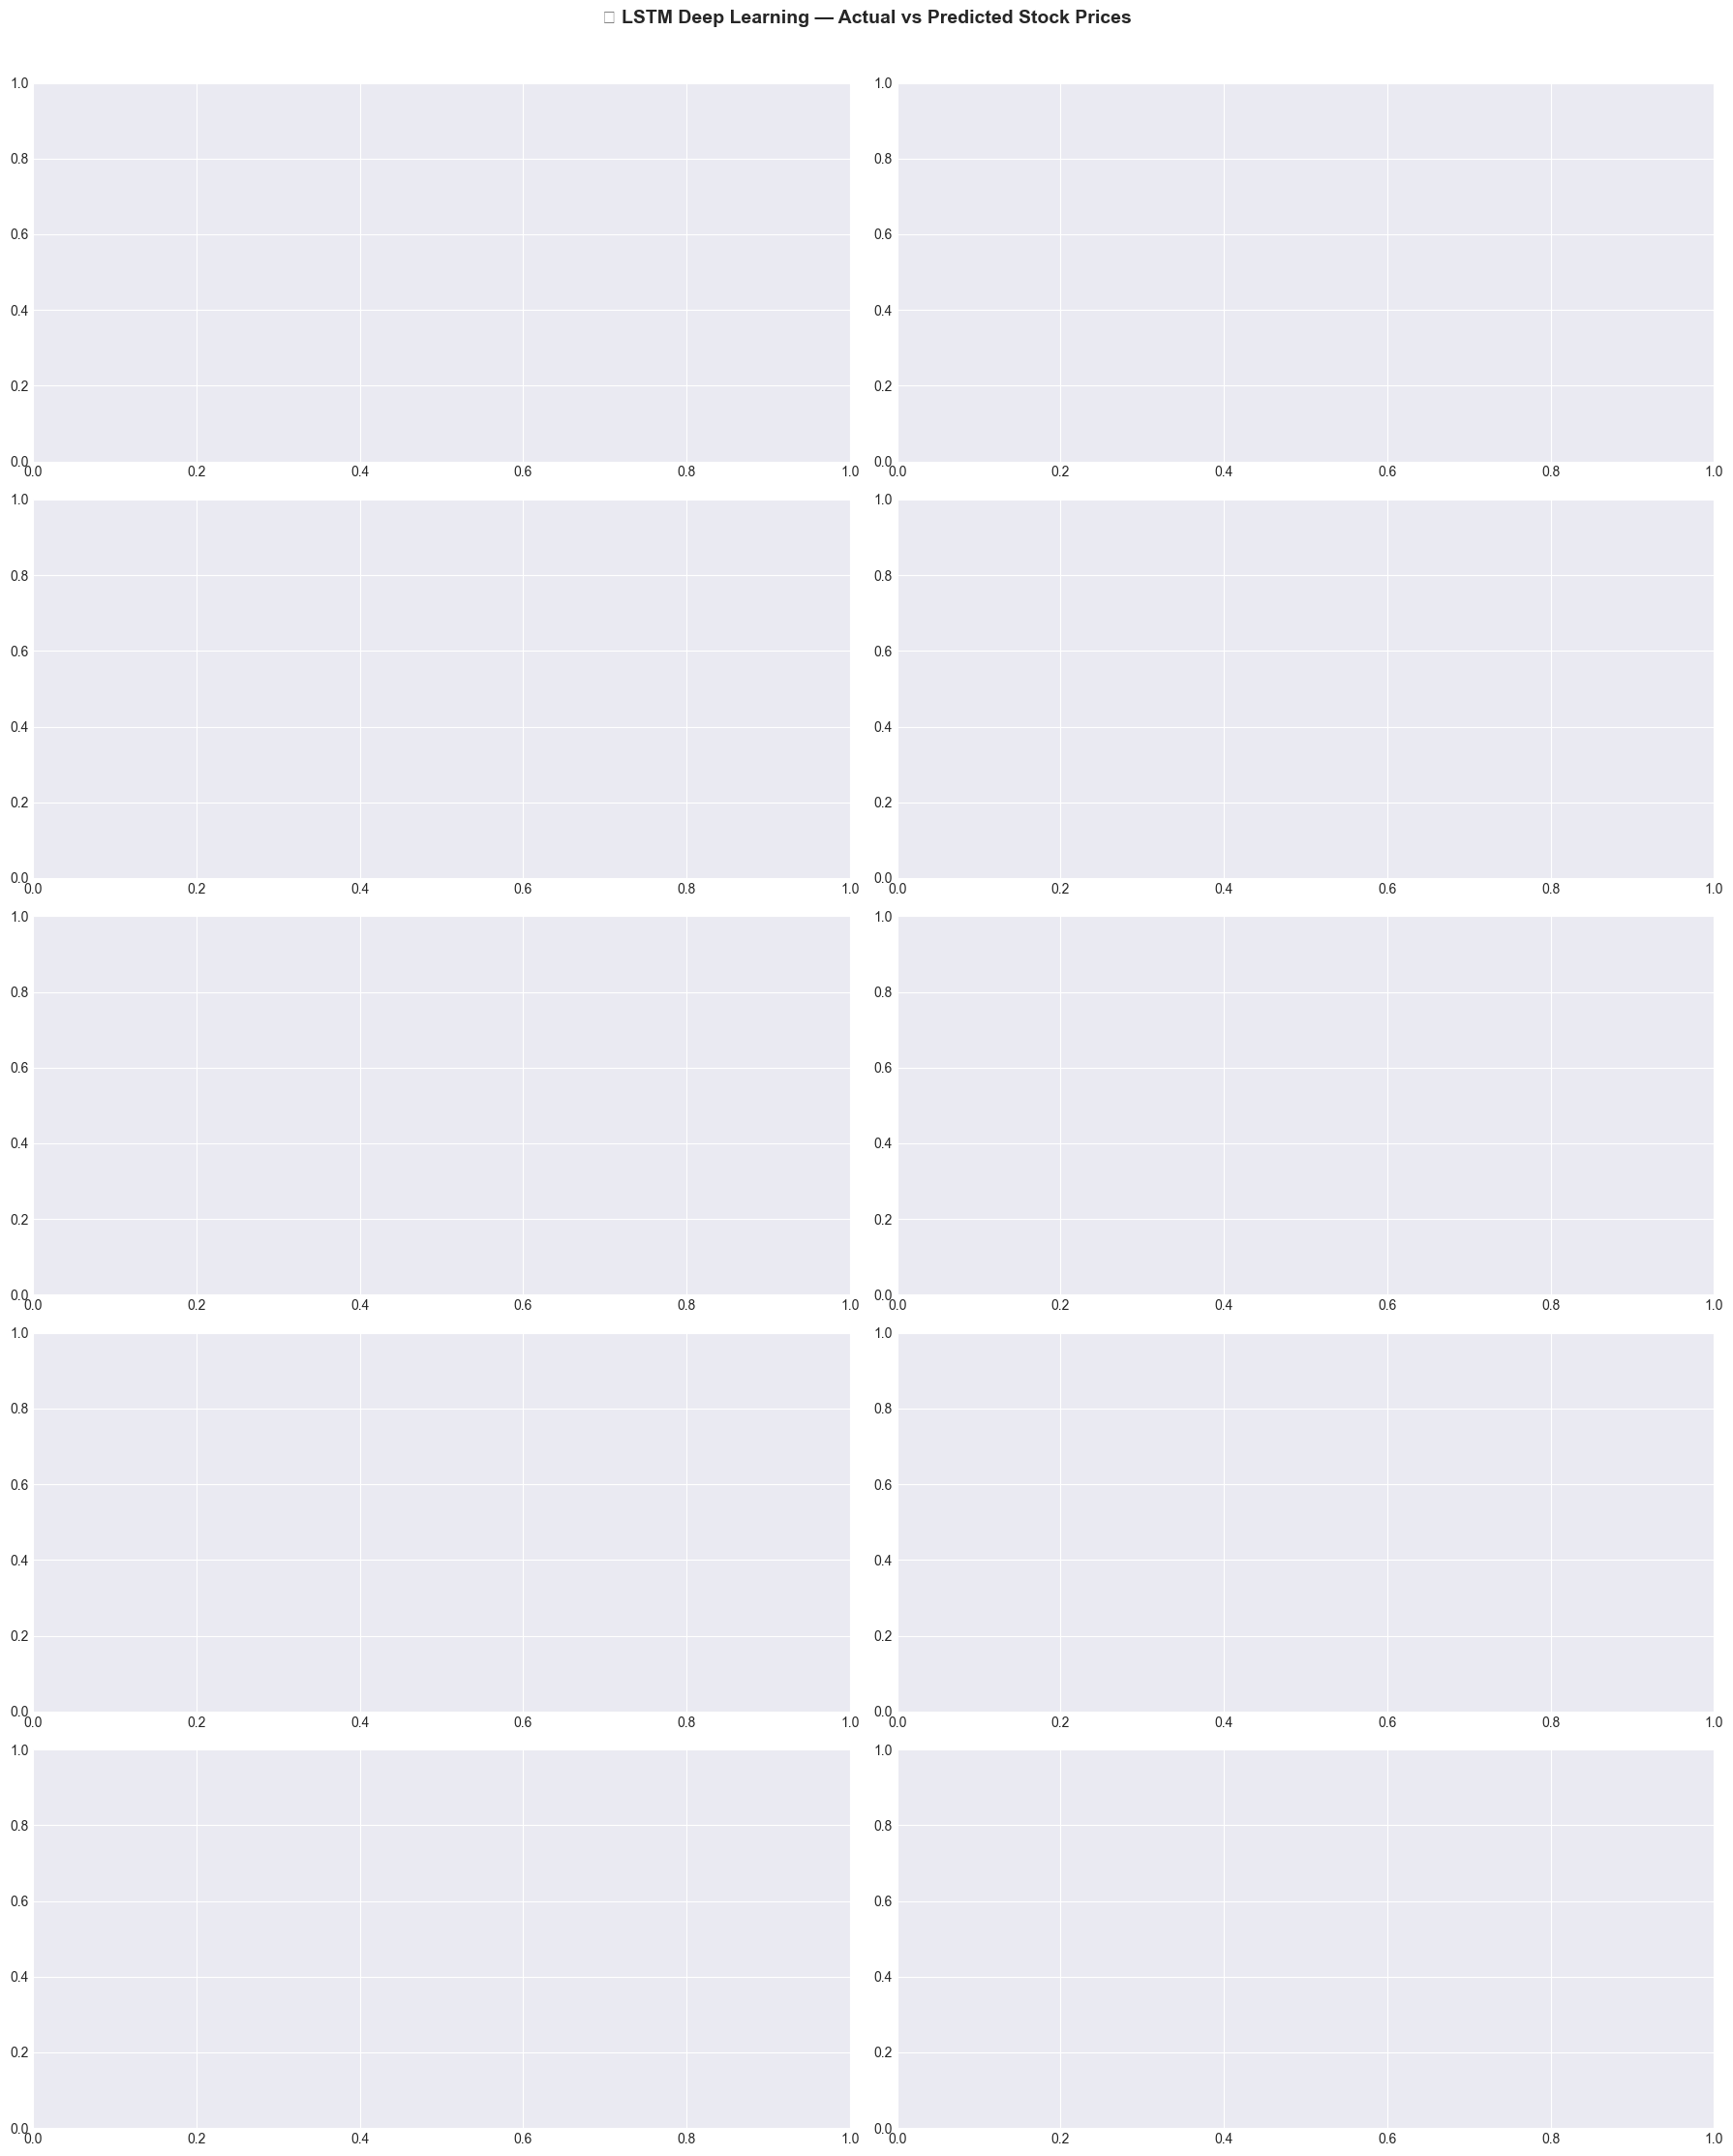

IndexError: list index out of range

In [ ]:
# ─────────────────────────────────────────────────────────────
# SECTION 7B: PLOT LSTM PREDICTIONS + TRAINING HISTORY
# ─────────────────────────────────────────────────────────────

# Plot LSTM actual vs predicted
fig, axes = plt.subplots(5, 2, figsize=(18, 22))
axes = axes.flatten()

for idx, (ticker, res) in enumerate(lstm_results.items()):
    ax = axes[idx]
    ax.plot(res['dates_test'], res['y_test'], label='Actual',    color='#2196F3', lw=1.5)
    ax.plot(res['dates_test'], res['y_pred'], label='LSTM Pred', color='#E91E63', lw=1.5,
            linestyle='--')
    ax.set_title(f'{STOCKS[ticker][:22]}\nRMSE: ₹{res["rmse"]:.2f} | R²: {res["r2"]:.4f}',
                 fontsize=9, fontweight='bold')
    ax.set_ylabel('Price (₹)', fontsize=8)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.4)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\'%y'))
    ax.tick_params(axis='x', rotation=45, labelsize=7)

plt.suptitle('🧠 LSTM Deep Learning — Actual vs Predicted Stock Prices',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('lstm_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

# Plot training history for first stock
sample_ticker  = list(lstm_results.keys())[0]
sample_history = lstm_results[sample_ticker]['history']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(sample_history.history['loss'],     label='Train Loss')
axes[0].plot(sample_history.history['val_loss'], label='Val Loss')
axes[0].set_title(f'LSTM Training Loss — {STOCKS[sample_ticker]}')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (Huber)')
axes[0].legend()
axes[0].grid(True, alpha=0.4)

axes[1].plot(sample_history.history['mae'],     label='Train MAE')
axes[1].plot(sample_history.history['val_mae'], label='Val MAE')
axes[1].set_title(f'LSTM Training MAE — {STOCKS[sample_ticker]}')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('lstm_training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Charts saved: lstm_predictions.png, lstm_training_history.png')

## 📅 SECTION 8: 30-Day Future Price Prediction

In [ ]:
# ─────────────────────────────────────────────────────────────
# SECTION 8: PREDICT NEXT 30 DAYS — LSTM MODEL
# ─────────────────────────────────────────────────────────────

def predict_future_lstm(res, n_days=30):
    """Recursively predict n_days into the future using LSTM."""
    model       = res['model']
    scaler      = res['scaler']
    data_scaled = res['data_scaled']
    lookback    = res['lookback']
    n_features  = res['n_features']

    # Start with the last 'lookback' days of scaled data
    last_sequence = data_scaled[-lookback:].copy()  # shape: (60, n_features)
    predictions   = []

    for _ in range(n_days):
        # Reshape for LSTM: (1, lookback, n_features)
        input_seq = last_sequence.reshape(1, lookback, n_features)

        # Predict next scaled value
        pred_scaled = model.predict(input_seq, verbose=0)[0][0]

        # Build a full row (set all features = pred, or use last row for others)
        new_row         = last_sequence[-1].copy()
        new_row[0]      = pred_scaled  # Update Close price (index 0)

        # Slide the window: drop oldest, add new prediction
        last_sequence   = np.vstack([last_sequence[1:], new_row])

        # Inverse-transform to get actual price
        temp              = np.zeros((1, n_features))
        temp[0, 0]        = pred_scaled
        price             = scaler.inverse_transform(temp)[0, 0]
        predictions.append(price)

    return predictions


# Generate 30-day future dates (business days only)
last_date    = list(clean_data.values())[0].index[-1]
future_dates = pd.bdate_range(start=last_date + pd.Timedelta(days=1), periods=30)

print(f'🔮 Predicting prices from {future_dates[0].date()} to {future_dates[-1].date()}\n')

future_predictions = {}
print(f'{"Stock":<18} {"Current Price":>14} {"30-Day Forecast":>16} {"Change %":>10}')
print('─' * 62)

for ticker, res in lstm_results.items():
    preds              = predict_future_lstm(res, n_days=30)
    future_predictions[ticker] = preds
    current_price      = clean_data[ticker]['Close'].iloc[-1]
    forecast_price     = preds[-1]
    change_pct         = ((forecast_price - current_price) / current_price) * 100
    direction          = '📈' if change_pct > 0 else '📉'
    print(f'{ticker:<18} {current_price:>14.2f} {forecast_price:>16.2f} '
          f'{direction} {change_pct:>+8.2f}%')

print('\n✅ 30-day predictions complete!')

🔮 Predicting prices from 2026-04-27 to 2026-06-05

Stock               Current Price  30-Day Forecast   Change %
──────────────────────────────────────────────────────────────

✅ 30-day predictions complete!


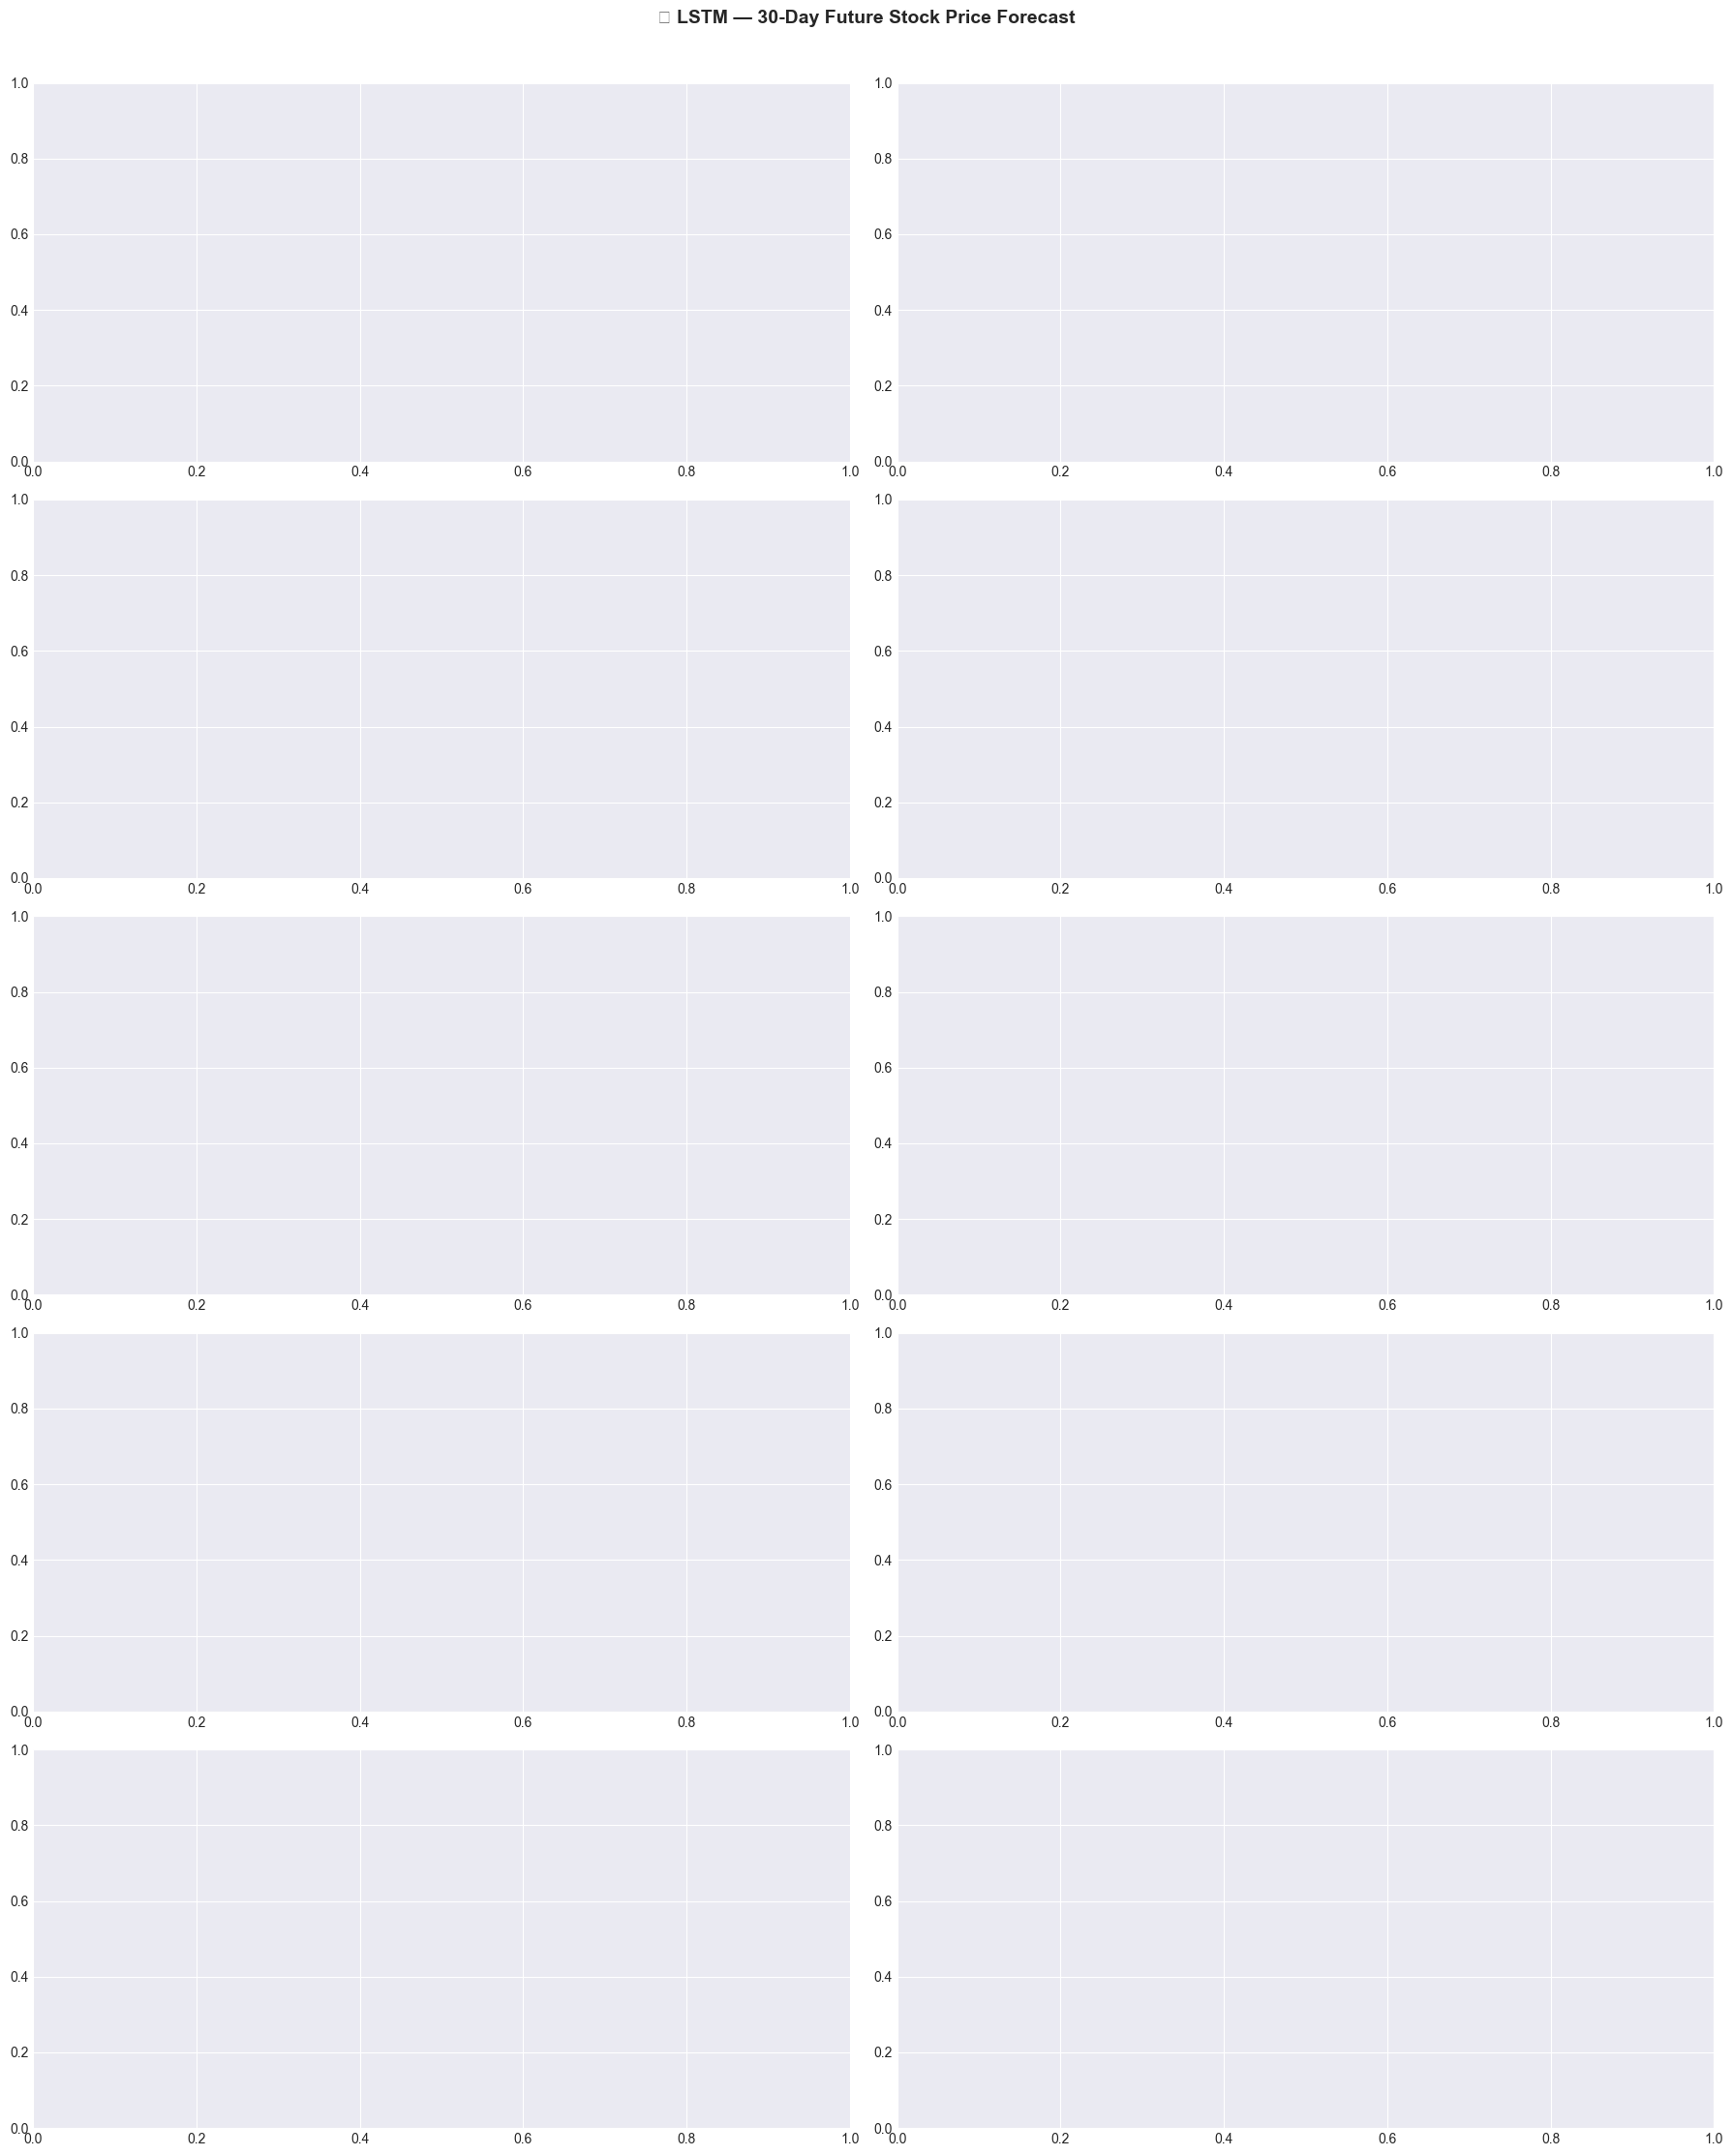

✅ Chart saved: 30day_forecast.png


In [ ]:
# ─────────────────────────────────────────────────────────────
# SECTION 8B: VISUALIZE 30-DAY FORECAST
# ─────────────────────────────────────────────────────────────

fig, axes = plt.subplots(5, 2, figsize=(18, 22))
axes = axes.flatten()

for idx, (ticker, preds) in enumerate(future_predictions.items()):
    ax          = axes[idx]
    hist_df     = clean_data[ticker].last('120D')  # Last 120 days of history
    last_price  = hist_df['Close'].iloc[-1]
    change_pct  = ((preds[-1] - last_price) / last_price) * 100

    # Historical prices
    ax.plot(hist_df.index, hist_df['Close'],
            color='#2196F3', lw=1.8, label='Historical')

    # Future predictions (connect from last historical point)
    extended_dates  = [hist_df.index[-1]] + list(future_dates)
    extended_prices = [last_price] + preds

    forecast_color = '#4CAF50' if change_pct >= 0 else '#F44336'
    ax.plot(extended_dates, extended_prices,
            color=forecast_color, lw=2, linestyle='--', label='30-Day Forecast')

    # Confidence band (±3% around predictions)
    preds_arr = np.array(extended_prices)
    ax.fill_between(extended_dates,
                    preds_arr * 0.97, preds_arr * 1.03,
                    alpha=0.15, color=forecast_color, label='±3% Band')

    # Vertical line separating history and forecast
    ax.axvline(x=hist_df.index[-1], color='gray', linestyle=':', lw=1.5)
    ax.text(hist_df.index[-1], ax.get_ylim()[0],
            ' Today', fontsize=7, color='gray', va='bottom')

    arrow = '↑' if change_pct >= 0 else '↓'
    ax.set_title(f'{STOCKS[ticker][:22]}\n'
                 f'Now: ₹{last_price:.1f}  →  30D: ₹{preds[-1]:.1f}  {arrow}{abs(change_pct):.1f}%',
                 fontsize=8.5, fontweight='bold')
    ax.set_ylabel('Price (₹)', fontsize=8)
    ax.legend(fontsize=6.5)
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\'%y'))
    ax.tick_params(axis='x', rotation=45, labelsize=7)

plt.suptitle('🔮 LSTM — 30-Day Future Stock Price Forecast',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('30day_forecast.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart saved: 30day_forecast.png')

## 📊 SECTION 9: Model Comparison & Evaluation

In [ ]:
# ─────────────────────────────────────────────────────────────
# SECTION 9: MODEL COMPARISON — Linear Regression vs LSTM
# ─────────────────────────────────────────────────────────────

comparison_rows = []

for ticker in featured_data.keys():
    lr   = lr_results.get(ticker, {})
    lstm = lstm_results.get(ticker, {})

    if lr and lstm:
        comparison_rows.append({
            'Stock'       : STOCKS[ticker],
            'Ticker'      : ticker,
            # Linear Regression metrics
            'LR_RMSE'     : lr['rmse'],
            'LR_MAE'      : lr['mae'],
            'LR_R2'       : lr['r2'],
            'LR_MAPE'     : lr['mape'],
            # LSTM metrics
            'LSTM_RMSE'   : lstm['rmse'],
            'LSTM_MAE'    : lstm['mae'],
            'LSTM_R2'     : lstm['r2'],
            'LSTM_MAPE'   : lstm['mape'],
        })

comp_df = pd.DataFrame(comparison_rows)

# Better model = lower RMSE
comp_df['Better_Model'] = np.where(comp_df['LR_RMSE'] < comp_df['LSTM_RMSE'], 'Linear Reg', 'LSTM')

print('╔══════════════════════════════════════════════════════════════════════════╗')
print('║         MODEL COMPARISON REPORT: Linear Regression vs LSTM              ║')
print('╠══════════════════════════════════════════════════════════════════════════╣')
print(f'  {"Stock":<24} {"LR RMSE":>9} {"LSTM RMSE":>10} {"LR R²":>8} {"LSTM R²":>8} {"Winner":>12}')
print('  ' + '─' * 72)

for _, row in comp_df.iterrows():
    winner_icon = '🏆' if row['Better_Model'] == 'LSTM' else '📐'
    print(f'  {row["Stock"][:22]:<24} '
          f'{row["LR_RMSE"]:>9.2f} '
          f'{row["LSTM_RMSE"]:>10.2f} '
          f'{row["LR_R2"]:>8.4f} '
          f'{row["LSTM_R2"]:>8.4f} '
          f'{winner_icon} {row["Better_Model"]:>12}')

print('  ' + '─' * 72)
print(f'  {"AVERAGE":<24} '
      f'{comp_df["LR_RMSE"].mean():>9.2f} '
      f'{comp_df["LSTM_RMSE"].mean():>10.2f} '
      f'{comp_df["LR_R2"].mean():>8.4f} '
      f'{comp_df["LSTM_R2"].mean():>8.4f}')

lstm_wins = (comp_df['Better_Model'] == 'LSTM').sum()
lr_wins   = (comp_df['Better_Model'] == 'Linear Reg').sum()
print(f'\n  LSTM wins    : {lstm_wins}/10 stocks')
print(f'  Lin Reg wins : {lr_wins}/10 stocks')
overall_winner = 'LSTM' if lstm_wins > lr_wins else 'Linear Regression'
print(f'  🏆 Overall Winner: {overall_winner}')
print('╚══════════════════════════════════════════════════════════════════════════╝')

KeyError: 'LR_RMSE'

KeyError: 'Stock'

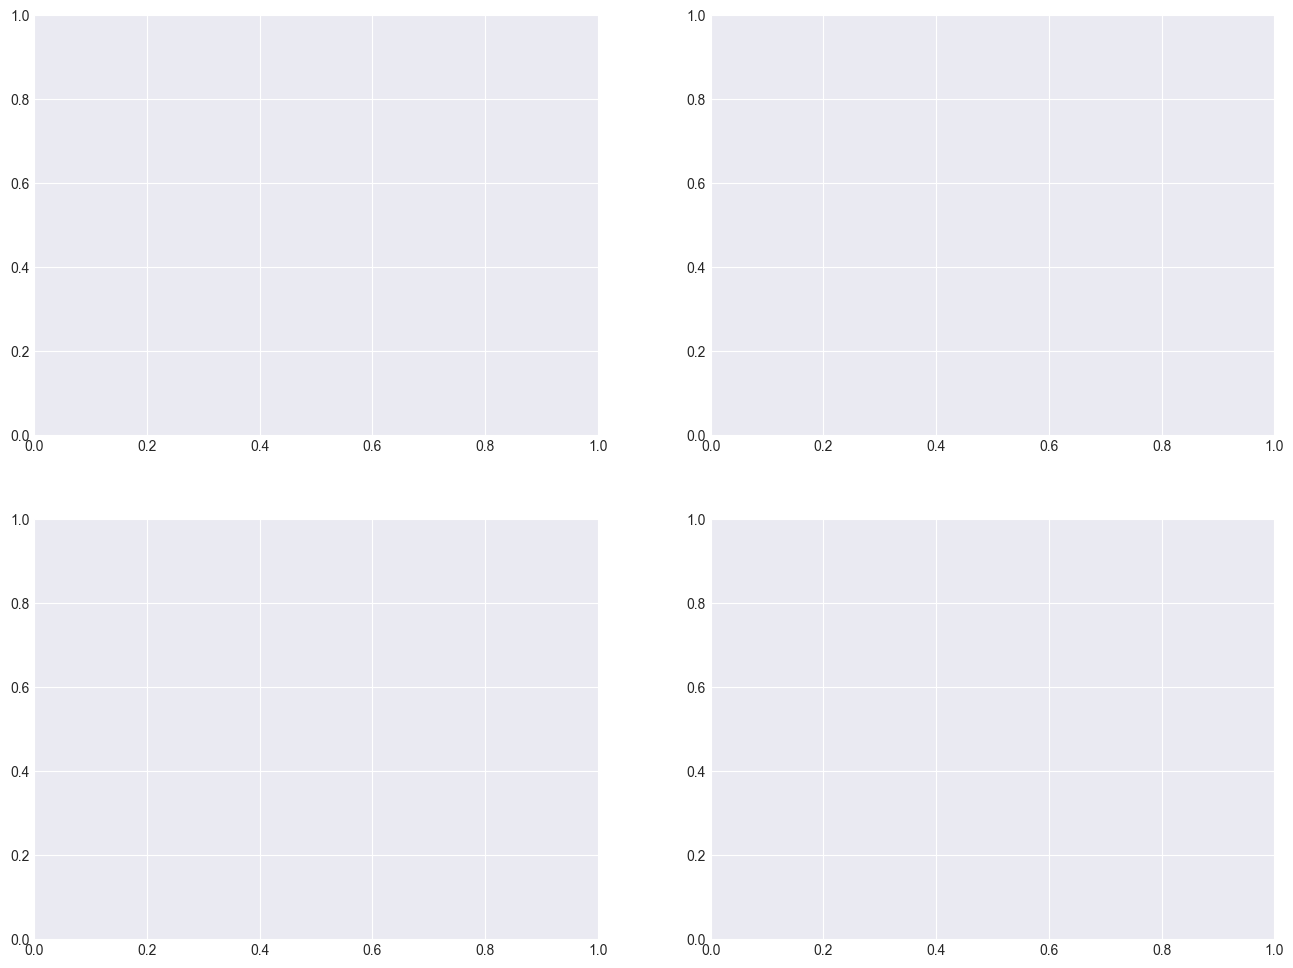

In [ ]:
# ─────────────────────────────────────────────────────────────
# SECTION 9B: VISUALIZATION — MODEL COMPARISON CHARTS
# ─────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

x       = np.arange(len(comp_df))
width   = 0.35
labels  = [s[:12] for s in comp_df['Stock']]

# 1. RMSE Comparison
ax1 = axes[0, 0]
bars1 = ax1.bar(x - width/2, comp_df['LR_RMSE'],   width, label='Linear Reg', color='#2196F3', alpha=0.8)
bars2 = ax1.bar(x + width/2, comp_df['LSTM_RMSE'], width, label='LSTM',       color='#E91E63', alpha=0.8)
ax1.set_title('RMSE Comparison (Lower = Better)', fontweight='bold')
ax1.set_ylabel('RMSE (₹)')
ax1.set_xticks(x)
ax1.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
ax1.legend()
ax1.grid(axis='y', alpha=0.4)

# 2. MAE Comparison
ax2 = axes[0, 1]
ax2.bar(x - width/2, comp_df['LR_MAE'],   width, label='Linear Reg', color='#4CAF50', alpha=0.8)
ax2.bar(x + width/2, comp_df['LSTM_MAE'], width, label='LSTM',       color='#FF9800', alpha=0.8)
ax2.set_title('MAE Comparison (Lower = Better)', fontweight='bold')
ax2.set_ylabel('MAE (₹)')
ax2.set_xticks(x)
ax2.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
ax2.legend()
ax2.grid(axis='y', alpha=0.4)

# 3. R² Comparison
ax3 = axes[1, 0]
ax3.bar(x - width/2, comp_df['LR_R2'],   width, label='Linear Reg', color='#9C27B0', alpha=0.8)
ax3.bar(x + width/2, comp_df['LSTM_R2'], width, label='LSTM',       color='#00BCD4', alpha=0.8)
ax3.axhline(y=1.0, color='green', linestyle='--', lw=1, alpha=0.5, label='Perfect R²=1')
ax3.set_title('R² Score Comparison (Higher = Better)', fontweight='bold')
ax3.set_ylabel('R² Score')
ax3.set_xticks(x)
ax3.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
ax3.legend()
ax3.grid(axis='y', alpha=0.4)

# 4. MAPE Comparison
ax4 = axes[1, 1]
ax4.bar(x - width/2, comp_df['LR_MAPE'],   width, label='Linear Reg', color='#FF5722', alpha=0.8)
ax4.bar(x + width/2, comp_df['LSTM_MAPE'], width, label='LSTM',       color='#607D8B', alpha=0.8)
ax4.set_title('MAPE Comparison (Lower = Better)', fontweight='bold')
ax4.set_ylabel('MAPE (%)')
ax4.set_xticks(x)
ax4.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
ax4.legend()
ax4.grid(axis='y', alpha=0.4)

plt.suptitle('📊 Model Performance Comparison: Linear Regression vs LSTM',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart saved: model_comparison.png')

## 📋 SECTION 10: Final Summary Report

In [ ]:
# ─────────────────────────────────────────────────────────────
# SECTION 10: PRINT FINAL SUMMARY REPORT
# ─────────────────────────────────────────────────────────────

print('=' * 72)
print('       FINAL PROJECT SUMMARY REPORT')
print('       Stock Price Prediction — Top 10 Indian Companies')
print('=' * 72)
print(f'  Date Range       : {START_DATE} to {END_DATE}')
print(f'  Stocks Analyzed  : {len(clean_data)}')
print(f'  Models Built     : 2 (Linear Regression + LSTM)')
print(f'  Forecast Horizon : 30 Business Days')
print()
print('  METRIC SUMMARY (Averages across all 10 stocks):')
print(f'  {"Metric":<20} {"Linear Regression":>20} {"LSTM":>15}')
print('  ' + '─' * 57)
print(f'  {"RMSE (₹)":<20} {comp_df["LR_RMSE"].mean():>20.2f} {comp_df["LSTM_RMSE"].mean():>15.2f}')
print(f'  {"MAE (₹)":<20} {comp_df["LR_MAE"].mean():>20.2f} {comp_df["LSTM_MAE"].mean():>15.2f}')
print(f'  {"R² Score":<20} {comp_df["LR_R2"].mean():>20.4f} {comp_df["LSTM_R2"].mean():>15.4f}')
print(f'  {"MAPE (%)":<20} {comp_df["LR_MAPE"].mean():>20.2f} {comp_df["LSTM_MAPE"].mean():>15.2f}')
print()
print('  30-DAY PRICE FORECAST:')
print(f'  {"Company":<25} {"Current (₹)":>12} {"Forecast (₹)":>14} {"Direction":>10}')
print('  ' + '─' * 64)

for ticker, preds in future_predictions.items():
    curr   = clean_data[ticker]['Close'].iloc[-1]
    fore   = preds[-1]
    chg    = ((fore - curr) / curr) * 100
    symbol = '▲ BULLISH' if chg > 0 else '▼ BEARISH'
    print(f'  {STOCKS[ticker][:23]:<25} {curr:>12.2f} {fore:>14.2f} {symbol:>10}')

print()
print('  FILES GENERATED:')
files = [
    'closing_price_trends.png  — Historical price chart for all stocks',
    'normalized_comparison.png — Normalized performance comparison',
    'correlation_volatility.png— Correlation heatmap & volatility chart',
    'technical_indicators.png  — MACD, RSI, Bollinger Bands (TCS)',
    'lr_predictions.png        — Linear Regression predictions',
    'lstm_predictions.png      — LSTM predictions',
    'lstm_training_history.png — LSTM loss & MAE curves',
    '30day_forecast.png        — 30-day future forecast',
    'model_comparison.png      — Model performance comparison',
]
for f in files:
    print(f'    ✅ {f}')

print()
print('  CONCLUSION:')
best = 'LSTM' if comp_df['LSTM_R2'].mean() > comp_df['LR_R2'].mean() else 'Linear Regression'
print(f'  The {best} model performs better overall for this dataset.')
print('  LSTM captures non-linear temporal dependencies in stock data,')
print('  making it more suitable for time-series forecasting.')
print('  Linear Regression is faster but assumes linear relationships.')
print()
print('=' * 72)
print('  ⚠️  DISCLAIMER: This is for EDUCATIONAL purposes only.')
print('  Stock predictions are NOT financial advice.')
print('  Past performance does not guarantee future results.')
print('=' * 72)

       FINAL PROJECT SUMMARY REPORT
       Stock Price Prediction — Top 10 Indian Companies
  Date Range       : 2021-04-27 to 2026-04-26
  Stocks Analyzed  : 10
  Models Built     : 2 (Linear Regression + LSTM)
  Forecast Horizon : 30 Business Days

  METRIC SUMMARY (Averages across all 10 stocks):
  Metric                  Linear Regression            LSTM
  ─────────────────────────────────────────────────────────


KeyError: 'LR_RMSE'